# IT5006 Chicago Crime Prediction — MLP v2

芝加哥犯罪热点预测 | 多层感知机 + 逻辑回归基线 + 德克萨斯泛化测试

**全量运行约需 2-4 小时**（主要耗时：Step 06 MLP训练 + Step 07 Optuna调优）
每步完成后自动保存 pkl 中间文件，重启内核后可从任意步骤继续。

| Step | 内容 | 主要输出 |
|------|------|---------|
| 01 | 数据加载与验证 | `01_data_summary.png` |
| 02 | 空间网格划分（1km × 1km） | `02_grid_map.png` |
| 03 | 特征工程（滞后/滚动/空间） | `03_feature_distributions.png` |
| 04 | 训练测试分割 + 标准化 | `04_split_summary.png` |
| 05 | 逻辑回归基线 | `05_lr_roc_curves.png` |
| 06 | MLP 神经网络训练（核心） | `06_mlp_loss_curves.png`, `06_mlp_cv_auc_bars.png` |
| 07 | Optuna 超参数调优（可选）| `07_optuna_history.png` |
| 08 | 所有模型统一评估 | `08_roc_curves.png`, `08_confusion_matrices.png` |
| 09 | 置换特征重要性分析 | `09_feature_importance.png` |
| 10 | 网格分辨率敏感性（1km vs 500m）| `10_grid_sensitivity_comparison.png` |
| 11 | 模型性能对比汇总表 | `11_model_comparison_table.png` |
| 12 | 泛化测试（Chicago → Texas NIBRS）| `12_generalization_report.png` |

## 环境配置 & 全局常量

In [1]:
import os, pickle, warnings
warnings.filterwarnings('ignore')
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib import colors as mcolors
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (
    precision_score, recall_score, f1_score, roc_auc_score,
    roc_curve, confusion_matrix, classification_report
)
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

np.random.seed(42)
tf.random.set_seed(42)

# 路径配置
NOTEBOOK_DIR = os.getcwd()
BASE_DIR     = os.path.dirname(NOTEBOOK_DIR)
CLEAN_CSV    = os.path.join(BASE_DIR, 'data_cleam（数据清洗）', 'Cleaned_Chicago_Crimes_2015_2024.csv')
RAW_CSV      = os.path.join(BASE_DIR, 'data_set（数据集）', 'Crimes_-_2001_to_Present_20260130.csv')
TEXAS_CSV    = os.path.join(BASE_DIR, 'Texas-Standard Dataset', 'tx_external_shared_final_42cols.csv')
OUTPUT_DIR   = os.path.join(NOTEBOOK_DIR, 'outputs')
os.makedirs(OUTPUT_DIR, exist_ok=True)

# 地理参数
RES                = 0.01
LAT_MIN, LAT_MAX   = 41.60, 42.10
LON_MIN, LON_MAX   = -87.95, -87.50
ACTIVITY_THRESHOLD = 50
CHICAGO_BASE_LAT   = 41.85
CHICAGO_BASE_LON   = -87.65

# 模型超参数
TOP3            = ['THEFT', 'BATTERY', 'CRIMINAL DAMAGE']
N_SPLITS        = 5
EPOCHS          = 50
BATCH_SIZE      = 512
RANDOM_SEED     = 42
LAG_WEEKS       = [1, 2, 4, 8, 13, 26, 52]
ROLLING_WINDOWS = [4, 12, 26]
TRAIN_YEARS     = (2015, 2024)
TEST_YEAR       = 2025

print('✓ 配置完成')
print(f'TensorFlow: {tf.__version__}')
print(f'OUTPUT_DIR: {OUTPUT_DIR}')


✓ 配置完成
TensorFlow: 2.20.0
OUTPUT_DIR: d:\Trae_Projects\It5006\model_mlp_v2\outputs


## Step 01 — 数据加载与验证

In [ ]:
# 导入共享配置


# ── 工具函数 ──────────────────────────────────────────────────────────────────

def load_train_data(path: str) -> pd.DataFrame:
    """
    加载清洗后的训练数据（2015-2024）。

    只选取建模所需的列，避免加载 411MB 文件中无用的字段。
    Date 列解析为 datetime 格式，便于后续提取时间特征。
    """
    print(f'  正在加载训练数据: {path}')
    df = pd.read_csv(
        path,
        usecols=[
            'Case Number', 'Date', 'Primary Type',
            'District', 'Community Area',
            'Year', 'Latitude', 'Longitude',
            'Hour', 'Month', 'DayOfWeek'
        ],
        parse_dates=['Date']
    )
    print(f'  已加载 {len(df):,} 条记录，年份范围: {df["Year"].min()}-{df["Year"].max()}')
    return df


def load_test_data(path: str, test_year: int = 2025) -> pd.DataFrame:
    """
    从原始数据集中提取指定年份的测试数据。

    原始文件包含 2001 年至今的所有数据（约 2.3GB），
    我们只取 test_year 年的记录，并手动派生时间特征列，
    使其与训练数据的列结构一致。
    """
    print(f'  正在从原始文件加载 {test_year} 年测试数据: {path}')
    df_raw = pd.read_csv(
        path,
        usecols=[
            'Case Number', 'Date', 'Primary Type',
            'District', 'Community Area',
            'Year', 'Latitude', 'Longitude'
        ],
        parse_dates=['Date'],
        dayfirst=False  # 原始文件为 M/D/Y 格式
    )
    # 只保留测试年份
    df = df_raw[df_raw['Year'] == test_year].copy()

    # 从 Date 列派生与训练集一致的时间特征列
    df['Hour']      = df['Date'].dt.hour
    df['Month']     = df['Date'].dt.month
    df['DayOfWeek'] = df['Date'].dt.day_name()

    print(f'  已加载 {len(df):,} 条 {test_year} 年记录')
    return df


def validate_and_filter(df: pd.DataFrame, name: str,
                         lat_min: float, lat_max: float,
                         lon_min: float, lon_max: float) -> pd.DataFrame:
    """
    验证数据完整性并过滤无效坐标。

    步骤：
      1. 删除缺失经纬度的行（无法做空间建模）
      2. 过滤超出芝加哥边界框的异常坐标
    """
    n_before = len(df)
    df = df.dropna(subset=['Latitude', 'Longitude'])

    # 过滤边界框外的坐标（异常录入数据）
    df = df[
        df['Latitude'].between(lat_min, lat_max) &
        df['Longitude'].between(lon_min, lon_max)
    ].copy()

    n_after = len(df)
    print(f'  [{name}] 过滤前: {n_before:,} → 过滤后: {n_after:,} (丢弃 {n_before-n_after:,} 条无效坐标记录)')
    return df


def compute_top3(df_train: pd.DataFrame) -> list:
    """
    根据训练数据中的犯罪频率确定 Top3 犯罪类型。

    为什么只用训练数据确定 Top3？
      避免数据泄漏——测试集（2025年）的犯罪分布不应影响建模决策。
    """
    top3 = df_train['Primary Type'].value_counts().head(3).index.tolist()
    print(f'  Top3 犯罪类型（训练数据）: {top3}')
    return top3


def plot_data_summary(df_train: pd.DataFrame, df_test: pd.DataFrame,
                      top3: list, out_path: str):
    """
    生成数据摘要可视化，包含 4 个子图：
      左上: 每年犯罪记录数（训练集）
      右上: 每年犯罪记录数（测试集与训练集对比）
      下左: Top15 犯罪类型频率（训练集）
      下右: Top3 犯罪类型在训练/测试集中的占比对比

    运行后请检查：
      - 年份分布是否连续（无缺失年份）
      - Top3 犯罪类型在训练和测试集中是否一致
    """
    fig = plt.figure(figsize=(16, 10))
    gs = gridspec.GridSpec(2, 2, hspace=0.4, wspace=0.35)

    # ── 子图1: 训练集每年记录数 ─────────────────────────────────────────────
    ax1 = fig.add_subplot(gs[0, 0])
    year_counts = df_train.groupby('Year').size()
    ax1.bar(year_counts.index, year_counts.values, color='steelblue', alpha=0.8)
    ax1.set_title('训练集: 每年犯罪记录数 (2015-2024)', fontsize=11)
    ax1.set_xlabel('年份')
    ax1.set_ylabel('记录数')
    for x, y in zip(year_counts.index, year_counts.values):
        ax1.text(x, y + 500, f'{y/1e4:.1f}W', ha='center', fontsize=7)
    ax1.grid(axis='y', alpha=0.3)

    # ── 子图2: 测试集月度记录数 ─────────────────────────────────────────────
    ax2 = fig.add_subplot(gs[0, 1])
    month_counts = df_test.groupby('Month').size()
    ax2.bar(month_counts.index, month_counts.values, color='darkorange', alpha=0.8)
    ax2.set_title('测试集: 月度犯罪记录数 (2025)', fontsize=11)
    ax2.set_xlabel('月份')
    ax2.set_ylabel('记录数')
    ax2.set_xticks(range(1, 13))
    ax2.grid(axis='y', alpha=0.3)

    # ── 子图3: Top15 犯罪类型（训练集）──────────────────────────────────────
    ax3 = fig.add_subplot(gs[1, 0])
    top15 = df_train['Primary Type'].value_counts().head(15)
    colors = ['#e74c3c' if t in top3 else 'steelblue' for t in top15.index]
    ax3.barh(range(len(top15)), top15.values[::-1], color=colors[::-1])
    ax3.set_yticks(range(len(top15)))
    ax3.set_yticklabels(top15.index[::-1], fontsize=8)
    ax3.set_title('训练集: Top15 犯罪类型（红色=建模目标）', fontsize=11)
    ax3.set_xlabel('犯罪总数')
    ax3.grid(axis='x', alpha=0.3)

    # ── 子图4: Top3 在训练/测试集的占比对比 ──────────────────────────────────
    ax4 = fig.add_subplot(gs[1, 1])
    x = np.arange(len(top3))
    width = 0.35

    train_pcts = [(df_train['Primary Type'] == c).sum() / len(df_train) * 100 for c in top3]
    test_pcts  = [(df_test['Primary Type']  == c).sum() / len(df_test)  * 100 for c in top3]

    ax4.bar(x - width/2, train_pcts, width, label='训练集 2015-2024', color='steelblue', alpha=0.8)
    ax4.bar(x + width/2, test_pcts,  width, label='测试集 2025',      color='darkorange', alpha=0.8)
    ax4.set_xticks(x)
    ax4.set_xticklabels([c.replace(' ', '\n') for c in top3], fontsize=9)
    ax4.set_ylabel('占全部犯罪的比例 (%)')
    ax4.set_title('Top3 犯罪类型在训练/测试集中的占比', fontsize=11)
    ax4.legend()
    ax4.grid(axis='y', alpha=0.3)

    plt.suptitle('Step 01 — 数据摘要', fontsize=14, fontweight='bold')
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'  图片已保存: {out_path}')


# ── 主流程 ────────────────────────────────────────────────────────────────────

def main():
    os.makedirs(OUTPUT_DIR, exist_ok=True)

    print('=' * 60)
    print('Step 01 — 数据加载与验证')
    print('=' * 60)

    # 1. 加载数据
    print('\n[1/4] 加载训练数据...')
    df_train = load_train_data(CLEAN_CSV)

    print('\n[2/4] 加载测试数据...')
    df_test = load_test_data(RAW_CSV, test_year=2025)

    # 2. 验证并过滤坐标
    print('\n[3/4] 过滤无效坐标...')
    df_train = validate_and_filter(df_train, '训练集', LAT_MIN, LAT_MAX, LON_MIN, LON_MAX)
    df_test  = validate_and_filter(df_test,  '测试集', LAT_MIN, LAT_MAX, LON_MIN, LON_MAX)

    # 3. 确定 Top3 犯罪类型
    print('\n[4/4] 确定 Top3 犯罪类型...')
    top3 = compute_top3(df_train)

    print('\n训练集各 Top3 类型记录数:')
    for c in top3:
        n = (df_train['Primary Type'] == c).sum()
        print(f'  {c}: {n:,} ({n/len(df_train)*100:.1f}%)')

    print('\n测试集各 Top3 类型记录数:')
    for c in top3:
        n = (df_test['Primary Type'] == c).sum()
        print(f'  {c}: {n:,} ({n/len(df_test)*100:.1f}%)')

    # 4. 保存中间数据
    print('\n保存中间数据...')
    with open(os.path.join(OUTPUT_DIR, '01_df_train.pkl'), 'wb') as f:
        pickle.dump(df_train, f)
    with open(os.path.join(OUTPUT_DIR, '01_df_test.pkl'), 'wb') as f:
        pickle.dump(df_test, f)
    with open(os.path.join(OUTPUT_DIR, '01_top3.pkl'), 'wb') as f:
        pickle.dump(top3, f)
    print('  已保存: 01_df_train.pkl, 01_df_test.pkl, 01_top3.pkl')

    # 5. 生成可视化
    print('\n生成数据摘要图...')
    plot_data_summary(
        df_train, df_test, top3,
        out_path=os.path.join(OUTPUT_DIR, '01_data_summary.png')
    )

    print('\n✓ Step 01 完成')
    print(f'  训练集: {len(df_train):,} 条记录')
    print(f'  测试集: {len(df_test):,} 条记录')
    print(f'  Top3 犯罪类型: {top3}')


main()

## Step 02 — 空间网格划分与活跃网格过滤

In [ ]:
# ── 核心函数（供 step10 导入复用）────────────────────────────────────────────

def assign_grid_vectorized(lat_series: pd.Series, lon_series: pd.Series,
                           res: float = RES) -> pd.Series:
    """
    将经纬度序列批量映射到网格单元 ID（向量化实现，速度远快于 apply）。

    网格 ID 格式: "{grid_lat:.3f}_{grid_lon:.3f}"
    例如: "41.870_-87.650" 表示纬度 41.87°、经度 -87.65° 的 1km 网格单元。

    计算方式：将坐标除以分辨率并取整，再乘回分辨率，得到网格左下角坐标。
    """
    grid_lat = (np.floor(lat_series / res) * res).round(3)
    grid_lon = (np.floor(lon_series / res) * res).round(3)
    # 格式化为固定小数位数的字符串，确保 ID 一致性
    return grid_lat.map('{:.3f}'.format) + '_' + grid_lon.map('{:.3f}'.format)


def filter_active_grids(df_train: pd.DataFrame,
                        threshold: int = ACTIVITY_THRESHOLD) -> pd.Index:
    """
    仅使用训练数据确定活跃网格集合。

    参数:
        df_train   : 已含 'grid_id' 列的训练 DataFrame
        threshold  : 最低犯罪次数阈值（默认 50）

    返回:
        活跃网格 ID 的 Index
    """
    grid_counts = df_train.groupby('grid_id').size()
    active = grid_counts[grid_counts >= threshold].index
    print(f'  总网格数: {len(grid_counts):,}  →  活跃网格数: {len(active):,} '
          f'(阈值 ≥ {threshold} 次)')
    return active


def add_grid_columns(df: pd.DataFrame, res: float = RES) -> pd.DataFrame:
    """
    为 DataFrame 添加 grid_id、grid_lat、grid_lon 三列。

    grid_lat / grid_lon 为数值型，方便 step03 做空间邻居计算。
    """
    df = df.copy()
    df['grid_id']  = assign_grid_vectorized(df['Latitude'], df['Longitude'], res)
    df['grid_lat'] = df['grid_id'].str.split('_').str[0].astype(float)
    df['grid_lon'] = df['grid_id'].str.split('_').str[1].astype(float)
    return df


def plot_grid_map(df_train: pd.DataFrame, active_grids: pd.Index, out_path: str):
    """
    可视化芝加哥活跃网格的空间分布。

    颜色深浅表示该网格的历史犯罪总量（对数刻度），
    可用于直观判断高危区域的地理分布。

    运行后请检查：
      - 活跃网格是否覆盖芝加哥城区（非偏远郊区）
      - 高犯罪密度区域是否与已知高危区域吻合（如市中心、South Side）
    """
    # 计算每个活跃网格的犯罪密度
    active_df = df_train[df_train['grid_id'].isin(active_grids)].copy()
    grid_stats = active_df.groupby(['grid_lat', 'grid_lon']).size().reset_index(name='count')

    fig, ax = plt.subplots(figsize=(10, 12))

    # 使用对数颜色映射，防止少数极高密度网格主导色阶
    sc = ax.scatter(
        grid_stats['grid_lon'],
        grid_stats['grid_lat'],
        c=np.log1p(grid_stats['count']),
        cmap='YlOrRd',
        s=15,
        alpha=0.8,
        linewidths=0
    )

    cbar = plt.colorbar(sc, ax=ax, fraction=0.03, pad=0.04)
    cbar.set_label('log(犯罪总数 + 1)', fontsize=10)

    # 标注典型地点（供对照参考）
    landmarks = {
        '市中心 Loop':     (-87.628, 41.880),
        "O'Hare 机场":    (-87.904, 41.980),
        'Midway 机场':    (-87.737, 41.786),
    }
    for name, (lon, lat) in landmarks.items():
        ax.annotate(name, xy=(lon, lat), fontsize=8, color='navy',
                    arrowprops=dict(arrowstyle='->', color='navy', lw=1),
                    xytext=(lon + 0.05, lat + 0.02))

    ax.set_xlabel('经度 (Longitude)', fontsize=11)
    ax.set_ylabel('纬度 (Latitude)', fontsize=11)
    ax.set_title(f'Step 02 — 芝加哥活跃网格空间分布\n'
                 f'网格分辨率: {RES}° ≈ 1km | 活跃网格数: {len(active_grids):,}',
                 fontsize=13)
    ax.set_xlim(LON_MIN - 0.02, LON_MAX + 0.02)
    ax.set_ylim(LAT_MIN - 0.02, LAT_MAX + 0.02)
    ax.grid(alpha=0.2)

    plt.tight_layout()
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'  图片已保存: {out_path}')


# ── 主流程 ────────────────────────────────────────────────────────────────────

def main():
    os.makedirs(OUTPUT_DIR, exist_ok=True)

    print('=' * 60)
    print('Step 02 — 空间网格划分与活跃网格过滤')
    print('=' * 60)

    # 1. 加载上一步的数据
    print('\n[1/4] 加载 Step 01 输出数据...')
    with open(os.path.join(OUTPUT_DIR, '01_df_train.pkl'), 'rb') as f:
        df_train = pickle.load(f)
    with open(os.path.join(OUTPUT_DIR, '01_df_test.pkl'), 'rb') as f:
        df_test = pickle.load(f)

    # 2. 分配网格 ID
    print('\n[2/4] 分配网格单元 ID...')
    df_train = add_grid_columns(df_train, res=RES)
    df_test  = add_grid_columns(df_test,  res=RES)
    print(f'  训练集唯一网格数: {df_train["grid_id"].nunique():,}')
    print(f'  测试集唯一网格数: {df_test["grid_id"].nunique():,}')

    # 3. 确定活跃网格（只用训练数据）
    print('\n[3/4] 过滤活跃网格（仅使用训练数据，防止测试集泄漏）...')
    active_grids = filter_active_grids(df_train, threshold=ACTIVITY_THRESHOLD)

    # 将训练集和测试集都限制在活跃网格范围内
    df_train = df_train[df_train['grid_id'].isin(active_grids)].copy()
    df_test  = df_test[df_test['grid_id'].isin(active_grids)].copy()

    print(f'  过滤后 — 训练集: {len(df_train):,} 条 | 测试集: {len(df_test):,} 条')

    # 4. 保存数据
    print('\n保存中间数据...')
    with open(os.path.join(OUTPUT_DIR, '02_df_train_gridded.pkl'), 'wb') as f:
        pickle.dump(df_train, f)
    with open(os.path.join(OUTPUT_DIR, '02_df_test_gridded.pkl'), 'wb') as f:
        pickle.dump(df_test, f)
    with open(os.path.join(OUTPUT_DIR, '02_active_grids.pkl'), 'wb') as f:
        pickle.dump(active_grids, f)
    print('  已保存: 02_df_train_gridded.pkl, 02_df_test_gridded.pkl, 02_active_grids.pkl')

    # 5. 可视化网格分布
    print('\n[4/4] 生成网格空间分布图...')
    plot_grid_map(
        df_train, active_grids,
        out_path=os.path.join(OUTPUT_DIR, '02_grid_map.png')
    )

    print('\n✓ Step 02 完成')
    print(f'  活跃网格数: {len(active_grids):,}')
    print(f'  每个网格单元约 {RES*111:.1f}km × {RES*111:.1f}km')


main()

## Step 03 — 特征工程（38维特征体系）

In [ ]:
# ── 特征工程函数（均可被 step10 导入复用）────────────────────────────────────

def add_temporal_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    为 DataFrame 添加时序循环编码特征。

    ISO 周、月份、小时均使用 sin/cos 双分量编码：
      - sin/cos 编码保持了时间的循环拓扑结构
      - 例如：第52周和第1周的欧氏距离与第1周和第2周相同
      - 普通数字编码无法表达这种周期性

    year_trend 捕捉 2015-2025 年间犯罪总量的长期趋势。
    """
    iso = df['Date'].dt.isocalendar()
    df = df.copy()
    df['iso_year']  = iso.year.astype(int)
    df['iso_week']  = iso.week.astype(int)
    # year_week 字符串用于 groupby 键（保留年份信息避免跨年混淆）
    df['year_week'] = (df['iso_year'].astype(str) + '-W' +
                       df['iso_week'].astype(str).str.zfill(2))

    # 周的循环编码（1-52）
    df['sin_week']  = np.sin(2 * np.pi * df['iso_week'] / 52)
    df['cos_week']  = np.cos(2 * np.pi * df['iso_week'] / 52)

    # 月份的循环编码（1-12）
    df['sin_month'] = np.sin(2 * np.pi * df['Month'] / 12)
    df['cos_month'] = np.cos(2 * np.pi * df['Month'] / 12)

    # 小时的循环编码（0-23）
    df['sin_hour']  = np.sin(2 * np.pi * df['Hour'] / 24)
    df['cos_hour']  = np.cos(2 * np.pi * df['Hour'] / 24)

    # 年份趋势（以 2015 年为基准）
    df['year_trend'] = df['iso_year'] - 2015
    return df


def build_weekly_agg(df_all: pd.DataFrame, top3: list) -> pd.DataFrame:
    """
    将事件级别数据聚合到 (grid_id × year_week) 级别。

    每一行代表某个网格单元在某一周内的犯罪统计摘要，
    这是模型的基本预测单元。

    为什么要合并训练集和测试集再聚合？
      2025年第1周（iso_week=1）的 lag_1w 需要引用 2024年第52周的数据。
      如果分开聚合，则无法计算这个跨年的滞后特征。
      聚合完成后，我们用 iso_year 列重新划分训练/测试。
    """
    agg = df_all.groupby(
        ['grid_id', 'year_week', 'iso_year', 'iso_week']
    ).agg(
        total_crimes   = ('Case Number', 'count'),
        sin_week       = ('sin_week',  'first'),    # 同一周内值相同，取第一个
        cos_week       = ('cos_week',  'first'),
        sin_month      = ('sin_month', 'mean'),     # 跨月的周取均值
        cos_month      = ('cos_month', 'mean'),
        sin_hour_mean  = ('sin_hour',  'mean'),     # 该周平均犯罪时段
        cos_hour_mean  = ('cos_hour',  'mean'),
        year_trend     = ('year_trend', 'first'),
        grid_lat       = ('grid_lat',  'first'),
        grid_lon       = ('grid_lon',  'first'),
    ).reset_index()

    # 添加每种目标犯罪类型的周计数
    for crime in top3:
        crime_weekly = (
            df_all[df_all['Primary Type'] == crime]
            .groupby(['grid_id', 'year_week'])
            .size()
            .reset_index(name=f'count_{crime}')
        )
        agg = agg.merge(crime_weekly, on=['grid_id', 'year_week'], how='left')
        # 未出现该类型犯罪的(网格, 周)填充 0
        agg[f'count_{crime}'] = agg[f'count_{crime}'].fillna(0).astype(int)

    # 按 (grid_id, year_week) 排序，这是后续 .shift() 正确计算的前提
    agg = agg.sort_values(['grid_id', 'year_week']).reset_index(drop=True)
    print(f'  聚合完成: {len(agg):,} 行 (grid × week 组合)')
    return agg


def add_lag_features(agg: pd.DataFrame, top3: list,
                     lag_weeks: list, rolling_windows: list) -> pd.DataFrame:
    """
    添加历史滞后特征和滚动均值特征。

    滞后特征原理：
      lag_Xw_total = 前 X 周该网格的总犯罪数
      shift(X) 保证当前周只看到 X 周前的数据，不会泄漏未来信息。

    滚动均值特征：
      先 shift(1) 再 rolling(W)，计算从 T-1 到 T-W 共 W 周的平均值，
      平滑短期噪音，捕捉中长期趋势。

    覆盖的时间尺度：
      1周 → 上周是否高犯罪（短期自回归）
      52周 → 去年同期（年度季节性）
    """
    # 按网格分组，对每个网格独立计算滞后（防止不同网格数据混串）
    grouped_total = agg.groupby('grid_id')['total_crimes']

    # 总犯罪数的多阶滞后
    for lag in lag_weeks:
        agg[f'lag_{lag}w_total'] = grouped_total.shift(lag)

    # 总犯罪数的滚动均值（先 shift 防止使用当前周数据）
    for window in rolling_windows:
        agg[f'roll_{window}w_total'] = (
            grouped_total.transform(
                lambda x: x.shift(1).rolling(window, min_periods=1).mean()
            )
        )

    # 各犯罪类型的专属滞后和滚动均值
    for crime in top3:
        col = f'count_{crime}'
        grouped_crime = agg.groupby('grid_id')[col]

        for lag in [1, 4, 13, 52]:
            agg[f'lag_{lag}w_{crime}'] = grouped_crime.shift(lag)

        # 4周滚动均值（捕捉月度犯罪趋势）
        agg[f'roll_4w_{crime}'] = grouped_crime.transform(
            lambda x: x.shift(1).rolling(4, min_periods=1).mean()
        )

    print(f'  滞后特征计算完成，当前列数: {len(agg.columns)}')
    return agg


def add_spatial_context(agg: pd.DataFrame, res: float = RES) -> pd.DataFrame:
    """
    添加空间上下文特征：周围 8 个相邻网格上一周的总犯罪数之和。

    空间自相关原理：犯罪往往在地理上聚集，
    一个网格的高犯罪率会影响周边网格的犯罪概率。

    防泄漏设计（两步）：
      Step A: 先计算当前周的 8 邻居犯罪总数（有泄漏）
      Step B: 再对此列做 shift(1)，转换为上一周邻居数据（无泄漏）

    8 个邻居方向：↖ ↑ ↗ ← → ↙ ↓ ↘
    """
    print('  计算空间邻居特征（8邻居，使用前一周数据）...')

    grid_week_total = agg[['grid_lat', 'grid_lon', 'year_week', 'total_crimes']].copy()
    neighbor_offsets = [(-1,-1), (-1,0), (-1,1), (0,-1), (0,1), (1,-1), (1,0), (1,1)]
    neighbor_sum = np.zeros(len(agg))

    for dlat, dlon in neighbor_offsets:
        ref = grid_week_total.copy()
        ref['grid_lat'] = (ref['grid_lat'] + dlat * res).round(3)
        ref['grid_lon'] = (ref['grid_lon'] + dlon * res).round(3)
        ref = ref.rename(columns={'total_crimes': '_nb'})
        merged = agg.merge(ref, on=['grid_lat', 'grid_lon', 'year_week'], how='left')
        neighbor_sum += merged['_nb'].fillna(0).values

    # Step A: 当前周邻居总数（此时有泄漏）
    agg['_neighbors_current'] = neighbor_sum

    # Step B: 向前移动一周，消除泄漏
    agg['neighbors_lag1w_sum'] = agg.groupby('grid_id')['_neighbors_current'].shift(1)
    agg = agg.drop(columns=['_neighbors_current'])

    print(f'  空间特征计算完成')
    return agg


def build_feature_cols(top3: list) -> list:
    """
    返回标准特征列名列表。

    统一定义特征列，确保训练/测试/调优各步骤使用完全相同的特征集。
    此函数的返回值会被保存为 03_feature_cols.pkl，
    所有后续步骤通过 pickle 加载而非重新定义，防止人为出错。
    """
    feature_cols = [
        # ① 时序循环特征
        'sin_week', 'cos_week', 'sin_month', 'cos_month',
        'sin_hour_mean', 'cos_hour_mean', 'year_trend',
        # ② 总犯罪滞后
        'lag_1w_total', 'lag_2w_total', 'lag_4w_total', 'lag_8w_total',
        'lag_13w_total', 'lag_26w_total', 'lag_52w_total',
        # ③ 总犯罪滚动均值
        'roll_4w_total', 'roll_12w_total', 'roll_26w_total',
        # ④ 空间上下文
        'neighbors_lag1w_sum',
        # ⑤ 网格坐标
        'grid_lat', 'grid_lon',
    ]
    # 为每个目标犯罪类型添加专属特征
    for crime in top3:
        feature_cols += [
            f'lag_1w_{crime}',
            f'lag_4w_{crime}',
            f'lag_13w_{crime}',
            f'lag_52w_{crime}',
            f'roll_4w_{crime}',
        ]
    return feature_cols


def plot_feature_distributions(agg: pd.DataFrame, feature_cols: list,
                               top3: list, out_path: str):
    """
    可视化关键特征的分布，帮助检验特征工程结果：
      左侧: 滞后特征的分布直方图（选取 6 个代表性特征）
      右侧: 特征相关性热力图（选取前 20 个特征）

    运行后请检查：
      - 滞后特征分布是否合理（不应全为 0 或极度偏态）
      - 热力图中同类型特征之间是否有较高相关性（正常现象）
      - 不同类型特征之间是否有信息互补（如时序和空间特征）
    """
    fig, axes = plt.subplots(2, 4, figsize=(18, 9))
    fig.suptitle('Step 03 — 关键特征分布检验（使用训练集 2015-2024 数据）',
                 fontsize=13, fontweight='bold')

    # 只使用训练集数据绘图（iso_year ≤ 2024）
    train_mask = agg['iso_year'].between(2015, 2024)
    agg_train = agg[train_mask].copy()

    # 选取 7 个代表性特征绘制分布图
    sample_feats = [
        'lag_1w_total', 'lag_4w_total', 'lag_52w_total',
        'roll_4w_total', 'neighbors_lag1w_sum',
        f'lag_1w_{top3[0]}', f'lag_52w_{top3[0]}'
    ]

    for i, (ax, feat) in enumerate(zip(axes.flat[:7], sample_feats)):
        data = agg_train[feat].dropna()
        ax.hist(data, bins=50, color='steelblue', alpha=0.7, edgecolor='none')
        ax.set_title(feat, fontsize=9)
        ax.set_xlabel('特征值')
        ax.set_ylabel('频次')
        ax.axvline(data.median(), color='red', linestyle='--', linewidth=1,
                   label=f'中位数={data.median():.1f}')
        ax.legend(fontsize=7)
        ax.grid(alpha=0.3)

    # 第8个子图：特征相关性热力图
    ax_heat = axes.flat[7]
    top_feats = feature_cols[:20]  # 取前20个特征
    corr = agg_train[top_feats].corr()
    # 简化标签（去掉过长的前缀）
    short_labels = [f.replace('lag_', 'l').replace('roll_', 'r').replace('_total', '') for f in top_feats]
    im = ax_heat.imshow(corr.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
    ax_heat.set_xticks(range(len(top_feats)))
    ax_heat.set_yticks(range(len(top_feats)))
    ax_heat.set_xticklabels(short_labels, rotation=90, fontsize=6)
    ax_heat.set_yticklabels(short_labels, fontsize=6)
    ax_heat.set_title('特征相关性矩阵（前20维）', fontsize=9)
    plt.colorbar(im, ax=ax_heat, fraction=0.046)

    plt.tight_layout()
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'  图片已保存: {out_path}')


# ── 主流程 ────────────────────────────────────────────────────────────────────

def main():
    os.makedirs(OUTPUT_DIR, exist_ok=True)

    print('=' * 60)
    print('Step 03 — 特征工程')
    print('=' * 60)

    # 1. 加载数据
    print('\n[1/6] 加载 Step 02 输出数据...')
    with open(os.path.join(OUTPUT_DIR, '02_df_train_gridded.pkl'), 'rb') as f:
        df_train = pickle.load(f)
    with open(os.path.join(OUTPUT_DIR, '02_df_test_gridded.pkl'), 'rb') as f:
        df_test = pickle.load(f)
    with open(os.path.join(OUTPUT_DIR, '01_top3.pkl'), 'rb') as f:
        top3 = pickle.load(f)
    print(f'  Top3 犯罪类型: {top3}')

    # 2. 添加时序特征
    print('\n[2/6] 添加时序循环编码特征...')
    df_train = add_temporal_features(df_train)
    df_test  = add_temporal_features(df_test)

    # 3. 合并训练+测试后聚合（跨年滞后特征需要连续的时间序列）
    print('\n[3/6] 合并数据并聚合到 (网格 × 周) 粒度...')
    df_all = pd.concat([df_train, df_test], ignore_index=True)
    print(f'  合并后总记录数: {len(df_all):,}')
    agg = build_weekly_agg(df_all, top3)

    # 4. 计算滞后特征
    print('\n[4/6] 计算历史滞后特征（防泄漏：shift ≥ 1）...')
    agg = add_lag_features(agg, top3, LAG_WEEKS, ROLLING_WINDOWS)

    # 5. 计算空间上下文特征
    print('\n[5/6] 计算空间邻居特征...')
    agg = add_spatial_context(agg, res=RES)

    # 6. 添加标签列（二分类：该周该网格是否发生此类犯罪）
    for crime in top3:
        agg[f'label_{crime}'] = (agg[f'count_{crime}'] > 0).astype(int)

    # 确认特征列
    feature_cols = build_feature_cols(top3)
    print(f'\n  总特征维度: {len(feature_cols)}')
    print(f'  特征列表: {feature_cols}')

    # 标签分布统计（仅训练集）
    print('\n  标签分布（训练集 2015-2024）:')
    train_mask = agg['iso_year'].between(2015, 2024)
    for crime in top3:
        n_pos = agg.loc[train_mask, f'label_{crime}'].sum()
        n_total = train_mask.sum()
        print(f'    {crime}: 正样本={n_pos:,} ({n_pos/n_total*100:.1f}%), '
              f'负样本={n_total-n_pos:,} ({(n_total-n_pos)/n_total*100:.1f}%)')

    # 保存数据
    print('\n保存中间数据...')
    with open(os.path.join(OUTPUT_DIR, '03_agg_features.pkl'), 'wb') as f:
        pickle.dump(agg, f)
    with open(os.path.join(OUTPUT_DIR, '03_feature_cols.pkl'), 'wb') as f:
        pickle.dump(feature_cols, f)
    print('  已保存: 03_agg_features.pkl, 03_feature_cols.pkl')

    # 可视化
    print('\n[6/6] 生成特征分布可视化...')
    plot_feature_distributions(
        agg, feature_cols, top3,
        out_path=os.path.join(OUTPUT_DIR, '03_feature_distributions.png')
    )

    print('\n✓ Step 03 完成')
    print(f'  特征矩阵形状: {agg.shape}')
    print(f'  特征维度: {len(feature_cols)}')


main()

## Step 04 — 训练/测试分割 + 标准化

In [ ]:
def split_and_clean(agg: pd.DataFrame, feature_cols: list, top3: list):
    """
    切分训练/测试集并删除含 NaN 的行。

    NaN 的来源：
      滞后特征（如 lag_52w）需要 52 周的历史数据。
      对于每个网格，最早的 52 行没有足够的历史，这些行的滞后特征为 NaN。
      删除这些行不会引入偏差，因为它们本来就缺少有效的特征值。

    返回:
      X_train, X_test (原始未标准化的 numpy array)
      y_train_dict, y_test_dict ({crime: array} 格式)
    """
    # 删除特征列中含有 NaN 的行
    agg_clean = agg.dropna(subset=feature_cols).copy()
    n_dropped = len(agg) - len(agg_clean)
    print(f'  删除含 NaN 的行: {n_dropped:,} 行 (因滞后特征计算不足)')
    print(f'  清洗后总行数: {len(agg_clean):,}')

    # 按年份切分
    train_mask = agg_clean['iso_year'].between(TRAIN_YEARS[0], TRAIN_YEARS[1])
    test_mask  = agg_clean['iso_year'] == TEST_YEAR

    X_train = agg_clean.loc[train_mask, feature_cols].values
    X_test  = agg_clean.loc[test_mask,  feature_cols].values

    y_train_dict = {
        crime: agg_clean.loc[train_mask, f'label_{crime}'].values
        for crime in top3
    }
    y_test_dict = {
        crime: agg_clean.loc[test_mask, f'label_{crime}'].values
        for crime in top3
    }

    print(f'\n  训练集形状: {X_train.shape} (2015-2024)')
    print(f'  测试集形状: {X_test.shape} (2025)')

    return X_train, X_test, y_train_dict, y_test_dict


def fit_and_scale(X_train: np.ndarray, X_test: np.ndarray):
    """
    对特征进行 Z-score 标准化。

    为什么需要标准化？
      MLP 对特征的量纲非常敏感。lag_52w_total 的值域可能是 [0, 500]，
      而 sin_week 的值域是 [-1, 1]。不标准化会导致梯度更新不均匀，
      训练不稳定，且收敛缓慢。

    为什么只在训练集上 fit？
      测试集代表"未来"，其统计特性在训练阶段不应被已知。
    """
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)   # 在训练集上计算均值和标准差
    X_test_scaled  = scaler.transform(X_test)         # 用训练集的统计量变换测试集
    print(f'  StandardScaler: 训练集均值范围 [{scaler.mean_.min():.3f}, {scaler.mean_.max():.3f}]')
    return X_train_scaled, X_test_scaled, scaler


def plot_class_balance(y_train_dict: dict, y_test_dict: dict,
                       top3: list, out_path: str):
    """
    可视化三种犯罪类型在训练集和测试集中的正负样本比例。

    运行后请检查：
      - 正样本比例（"发生犯罪"的比例）是否远低于 50%（类别不平衡）
      - 训练集和测试集的正样本比例是否大致一致（分布一致性）
      - 如果正样本比例极低（<10%），需要特别关注 class_weight 设置

    类别不平衡的直观解释：
      在 1km 网格 × 周 的粒度上，大多数格子在某一周并不会发生特定类型犯罪，
      因此正样本（"发生"）通常远少于负样本（"未发生"）。
    """
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle('Step 04 — 类别不平衡分析（正样本=该周该网格发生过此类犯罪）',
                 fontsize=13, fontweight='bold')

    for ax, crime in zip(axes, top3):
        y_tr = y_train_dict[crime]
        y_te = y_test_dict[crime]

        train_pos_pct = y_tr.mean() * 100
        test_pos_pct  = y_te.mean() * 100
        train_neg_pct = 100 - train_pos_pct
        test_neg_pct  = 100 - test_pos_pct

        x = np.arange(2)
        bars_pos = ax.bar(x, [train_pos_pct, test_pos_pct],
                          color='#e74c3c', alpha=0.8, label='正样本（犯罪发生）')
        bars_neg = ax.bar(x, [train_neg_pct, test_neg_pct],
                          bottom=[train_pos_pct, test_pos_pct],
                          color='#3498db', alpha=0.6, label='负样本（未发生）')

        ax.set_xticks(x)
        ax.set_xticklabels(['训练集\n2015-2024', '测试集\n2025'])
        ax.set_ylabel('比例 (%)')
        ax.set_ylim(0, 100)
        ax.set_title(f'{crime}', fontsize=11)

        # 标注正样本比例
        for xi, pct in zip(x, [train_pos_pct, test_pos_pct]):
            n_pos = int(y_tr.sum()) if xi == 0 else int(y_te.sum())
            n_total = len(y_tr) if xi == 0 else len(y_te)
            ax.text(xi, pct/2, f'{pct:.1f}%\n({n_pos:,}/{n_total:,})',
                    ha='center', va='center', color='white', fontsize=9, fontweight='bold')

        ax.legend(loc='upper right', fontsize=8)
        ax.grid(axis='y', alpha=0.3)

        # 在图上标注建议的 class_weight
        n_neg = len(y_tr) - int(y_tr.sum())
        n_pos = int(y_tr.sum())
        if n_pos > 0:
            weight = n_neg / n_pos
            ax.text(0.5, 0.95, f'建议 class_weight[1]={weight:.1f}',
                    transform=ax.transAxes, ha='center', va='top',
                    fontsize=8, color='darkred',
                    bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

    plt.tight_layout()
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'  图片已保存: {out_path}')


# ── 主流程 ────────────────────────────────────────────────────────────────────

def main():
    os.makedirs(OUTPUT_DIR, exist_ok=True)

    print('=' * 60)
    print('Step 04 — 数据分割与特征标准化')
    print('=' * 60)

    # 1. 加载数据
    print('\n[1/4] 加载 Step 03 输出数据...')
    with open(os.path.join(OUTPUT_DIR, '03_agg_features.pkl'), 'rb') as f:
        agg = pickle.load(f)
    with open(os.path.join(OUTPUT_DIR, '03_feature_cols.pkl'), 'rb') as f:
        feature_cols = pickle.load(f)
    with open(os.path.join(OUTPUT_DIR, '01_top3.pkl'), 'rb') as f:
        top3 = pickle.load(f)

    # 2. 切分训练/测试集
    print('\n[2/4] 切分训练/测试集并清除 NaN 行...')
    X_train, X_test, y_train_dict, y_test_dict = split_and_clean(agg, feature_cols, top3)

    # 打印各犯罪类型标签统计
    print('\n  训练集标签统计:')
    for crime in top3:
        y = y_train_dict[crime]
        n_pos = y.sum()
        print(f'    {crime}: 正={n_pos:,} ({n_pos/len(y)*100:.1f}%), '
              f'负={len(y)-n_pos:,}, class_weight[1]≈{(len(y)-n_pos)/max(n_pos,1):.1f}')

    # 3. 标准化
    print('\n[3/4] 特征标准化（StandardScaler fit on train only）...')
    X_train_scaled, X_test_scaled, scaler = fit_and_scale(X_train, X_test)

    # 4. 保存所有输出
    print('\n保存中间数据...')
    outputs = {
        '04_X_train.pkl':  X_train_scaled,
        '04_X_test.pkl':   X_test_scaled,
        '04_y_train.pkl':  y_train_dict,
        '04_y_test.pkl':   y_test_dict,
        '04_scaler.pkl':   scaler,
    }
    for fname, obj in outputs.items():
        with open(os.path.join(OUTPUT_DIR, fname), 'wb') as f:
            pickle.dump(obj, f)
    print(f'  已保存: {list(outputs.keys())}')

    # 5. 可视化
    print('\n[4/4] 生成类别不平衡可视化...')
    plot_class_balance(
        y_train_dict, y_test_dict, top3,
        out_path=os.path.join(OUTPUT_DIR, '04_split_summary.png')
    )

    print('\n✓ Step 04 完成')
    print(f'  X_train: {X_train_scaled.shape}')
    print(f'  X_test:  {X_test_scaled.shape}')
    print(f'\n  下一步: 运行 step05_baseline_lr.py（周震寰）和 step06_train_mlp.py 可并行执行')


main()

## Step 05 — 逻辑回归基线（周震宦负责）

In [ ]:
def run_lr_cv(X_train: np.ndarray, y_train_dict: dict,
              top3: list, n_splits: int = N_SPLITS,
              C: float = 1.0) -> tuple:
    """
    对每种犯罪类型运行时序交叉验证（TimeSeriesSplit）。

    为什么用 TimeSeriesSplit 而不是 StratifiedKFold？
      原版 notebook 使用 StratifiedKFold(shuffle=True)，会随机打乱时间顺序，
      导致验证集有时早于训练集（用"未来"训练，用"过去"验证），结果过于乐观。
      TimeSeriesSplit 保证每一折的验证集都在训练集之后。

    时序折叠示意（5折，总共约520周的训练数据）：
      Fold 1: 训练[W001-W104] → 验证[W105-W208]
      Fold 2: 训练[W001-W208] → 验证[W209-W312]
      Fold 3: 训练[W001-W312] → 验证[W313-W416]
      Fold 4: 训练[W001-W416] → 验证[W417-W520]
      Fold 5: 训练[W001-W520] → 验证[W521-...]
    """
    tscv = TimeSeriesSplit(n_splits=n_splits)
    cv_results = {crime: [] for crime in top3}
    final_models = {}

    for crime in top3:
        print(f'\n  [{crime}] 开始 {n_splits} 折时序交叉验证...')
        y_train = y_train_dict[crime]

        for fold, (tr_idx, val_idx) in enumerate(tscv.split(X_train)):
            # 逻辑回归：class_weight='balanced' 自动设置 n_neg/n_pos 权重
            model = LogisticRegression(
                C=C,
                class_weight='balanced',  # 等价于原版 MLP 的手动 class_weight
                max_iter=1000,
                random_state=RANDOM_SEED,
                solver='lbfgs'            # 适合中等规模数据集的优化器
            )
            model.fit(X_train[tr_idx], y_train[tr_idx])

            y_prob = model.predict_proba(X_train[val_idx])[:, 1]
            y_pred = (y_prob >= 0.5).astype(int)

            fold_metrics = {
                'fold':      fold + 1,
                'precision': precision_score(y_train[val_idx], y_pred, zero_division=0),
                'recall':    recall_score(y_train[val_idx], y_pred, zero_division=0),
                'f1':        f1_score(y_train[val_idx], y_pred, zero_division=0),
                'auc_roc':   roc_auc_score(y_train[val_idx], y_prob),
                'val_size':  len(val_idx),
            }
            cv_results[crime].append(fold_metrics)
            print(f'    Fold {fold+1}: Precision={fold_metrics["precision"]:.4f}  '
                  f'Recall={fold_metrics["recall"]:.4f}  '
                  f'F1={fold_metrics["f1"]:.4f}  '
                  f'AUC={fold_metrics["auc_roc"]:.4f}')

        # 汇总 CV 结果
        fold_df = pd.DataFrame(cv_results[crime])
        print(f'  [{crime}] CV 均值 ± 标准差:')
        for m in ['precision', 'recall', 'f1', 'auc_roc']:
            print(f'    {m:12s}: {fold_df[m].mean():.4f} ± {fold_df[m].std():.4f}')

        # 在全量训练集上训练最终模型
        final_model = LogisticRegression(
            C=C, class_weight='balanced', max_iter=1000,
            random_state=RANDOM_SEED, solver='lbfgs'
        )
        final_model.fit(X_train, y_train)
        final_models[crime] = final_model

    return cv_results, final_models


def evaluate_on_test(final_models: dict, X_test: np.ndarray,
                     y_test_dict: dict, top3: list) -> tuple:
    """
    在 2025 测试集上评估最终模型性能。

    返回:
      test_metrics : 标准格式字典（供 step11 使用）
      test_probs   : 预测概率（供绘制 ROC 曲线）
    """
    # 标准输出格式，step11 通过这个格式读取所有模型指标进行对比
    test_metrics = {}
    test_probs = {}

    print('\n  2025 测试集评估结果:')
    for crime in top3:
        y_test = y_test_dict[crime]
        y_prob = final_models[crime].predict_proba(X_test)[:, 1]
        y_pred = (y_prob >= 0.5).astype(int)

        test_probs[crime] = y_prob
        test_metrics[crime] = {
            'precision': precision_score(y_test, y_pred, zero_division=0),
            'recall':    recall_score(y_test, y_pred, zero_division=0),
            'f1':        f1_score(y_test, y_pred, zero_division=0),
            'auc_roc':   roc_auc_score(y_test, y_prob),
        }

        print(f'\n  [{crime}]')
        print(f'    Precision: {test_metrics[crime]["precision"]:.4f}')
        print(f'    Recall:    {test_metrics[crime]["recall"]:.4f}')
        print(f'    F1:        {test_metrics[crime]["f1"]:.4f}')
        print(f'    AUC-ROC:   {test_metrics[crime]["auc_roc"]:.4f}')
        print(f'    详细报告:\n{classification_report(y_test, y_pred, zero_division=0)}')

    return test_metrics, test_probs


def plot_roc_curves(final_models: dict, X_test: np.ndarray,
                    y_test_dict: dict, top3: list, out_path: str):
    """
    绘制三种犯罪类型的 ROC 曲线。

    ROC 曲线展示了在不同决策阈值下 TPR（真正率）与 FPR（假正率）的权衡。
    曲线越靠近左上角，模型越好。AUC = 0.5 为随机猜测基线。
    """
    fig, ax = plt.subplots(figsize=(8, 7))
    colors = ['steelblue', 'darkorange', 'green']

    for crime, color in zip(top3, colors):
        y_prob = final_models[crime].predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test_dict[crime], y_prob)
        auc = roc_auc_score(y_test_dict[crime], y_prob)
        ax.plot(fpr, tpr, color=color, linewidth=2.5,
                label=f'{crime} (AUC = {auc:.4f})')

    ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='随机基线 (AUC = 0.5)')
    ax.set_xlabel('假正率 (False Positive Rate)', fontsize=12)
    ax.set_ylabel('真正率 (True Positive Rate)', fontsize=12)
    ax.set_title('Step 05 — 逻辑回归基线 ROC 曲线（2025 测试集）', fontsize=13)
    ax.legend(loc='lower right', fontsize=10)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'  图片已保存: {out_path}')


def plot_confusion_matrices(final_models: dict, X_test: np.ndarray,
                             y_test_dict: dict, top3: list, out_path: str):
    """
    绘制三种犯罪类型的混淆矩阵。

    混淆矩阵帮助理解模型在哪类错误上更常犯：
      - 假阴性（FN）：漏报犯罪 → 对公共安全影响更大
      - 假阳性（FP）：误报犯罪 → 浪费警力资源
    """
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle('Step 05 — 逻辑回归基线混淆矩阵（2025 测试集，阈值=0.5）',
                 fontsize=12, fontweight='bold')

    for ax, crime in zip(axes, top3):
        y_test = y_test_dict[crime]
        y_pred = (final_models[crime].predict_proba(X_test)[:, 1] >= 0.5).astype(int)
        cm = confusion_matrix(y_test, y_pred)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                    xticklabels=['预测:未发生', '预测:发生'],
                    yticklabels=['实际:未发生', '实际:发生'],
                    annot_kws={'size': 12})
        ax.set_title(crime, fontsize=11)

        # 计算并标注漏报率（Recall 的补数）
        if cm.shape == (2, 2) and cm[1].sum() > 0:
            miss_rate = cm[1, 0] / cm[1].sum() * 100
            ax.set_xlabel(f'漏报率（犯罪漏检）= {miss_rate:.1f}%', fontsize=9)

    plt.tight_layout()
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'  图片已保存: {out_path}')


# ── 主流程 ────────────────────────────────────────────────────────────────────

def main():
    os.makedirs(OUTPUT_DIR, exist_ok=True)

    print('=' * 60)
    print('Step 05 — 逻辑回归基线模型（周震寰）')
    print('=' * 60)

    # 1. 加载数据（由 step04 预处理完毕）
    print('\n[1/5] 加载 Step 04 输出数据...')
    with open(os.path.join(OUTPUT_DIR, '04_X_train.pkl'), 'rb') as f:
        X_train = pickle.load(f)
    with open(os.path.join(OUTPUT_DIR, '04_X_test.pkl'), 'rb') as f:
        X_test = pickle.load(f)
    with open(os.path.join(OUTPUT_DIR, '04_y_train.pkl'), 'rb') as f:
        y_train_dict = pickle.load(f)
    with open(os.path.join(OUTPUT_DIR, '04_y_test.pkl'), 'rb') as f:
        y_test_dict = pickle.load(f)
    with open(os.path.join(OUTPUT_DIR, '01_top3.pkl'), 'rb') as f:
        top3 = pickle.load(f)

    print(f'  X_train: {X_train.shape}, X_test: {X_test.shape}')

    # 2. 时序交叉验证
    print('\n[2/5] 运行时序交叉验证（TimeSeriesSplit）...')
    cv_results, final_models = run_lr_cv(X_train, y_train_dict, top3, N_SPLITS)

    # 3. 测试集评估
    print('\n[3/5] 在 2025 测试集上评估...')
    test_metrics, test_probs = evaluate_on_test(final_models, X_test, y_test_dict, top3)

    # 4. 保存结果
    print('\n保存结果...')
    with open(os.path.join(OUTPUT_DIR, '05_lr_cv_results.pkl'), 'wb') as f:
        pickle.dump(cv_results, f)
    with open(os.path.join(OUTPUT_DIR, '05_lr_final_models.pkl'), 'wb') as f:
        pickle.dump(final_models, f)
    # ★ 标准输出格式：step11 通过读取此文件进行模型对比
    with open(os.path.join(OUTPUT_DIR, '05_lr_metrics.pkl'), 'wb') as f:
        pickle.dump(test_metrics, f)
    print('  已保存: 05_lr_cv_results.pkl, 05_lr_final_models.pkl, 05_lr_metrics.pkl')

    # 5. 可视化
    print('\n[4/5] 绘制 ROC 曲线...')
    plot_roc_curves(final_models, X_test, y_test_dict, top3,
                    out_path=os.path.join(OUTPUT_DIR, '05_lr_roc_curves.png'))

    print('\n[5/5] 绘制混淆矩阵...')
    plot_confusion_matrices(final_models, X_test, y_test_dict, top3,
                            out_path=os.path.join(OUTPUT_DIR, '05_lr_confusion_matrices.png'))

    print('\n✓ Step 05 完成 — 逻辑回归基线建立')
    print('\n  测试集 AUC-ROC 汇总:')
    for crime in top3:
        print(f'    {crime}: {test_metrics[crime]["auc_roc"]:.4f}')
    print('\n  提示: 以上 AUC 是 MLP 需要超越的基准线')


main()

## Step 06 — MLP 神经网络训练（核心）

Step 06 — MLP 神经网络训练（改进版）
  关键改进: StratifiedKFold → TimeSeriesSplit（防止时序泄漏）
  模型将保存到磁盘（后续步骤无需重训）

[1/5] 加载 Step 04 输出数据...
  X_train: (262748, 35), X_test: (29577, 35)

  MLP 模型架构:


Model: "crime_mlp"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51,969 (203.00 KB)

 Trainable params: 51,201 (200.00 KB)

 Non-trainable params: 768 (3.00 KB)


[2/5] 运行时序交叉验证（5 折）...

交叉验证: THEFT
  负:正 = 86,549:176,199  →  class_weight[1] = 0.5
  Fold 1: P=0.8400  R=0.7322  F1=0.7824  AUC=0.7971  (epochs=24)
  Fold 2: P=0.8220  R=0.6052  F1=0.6971  AUC=0.7604  (epochs=20)
  Fold 3: P=0.8892  R=0.8659  F1=0.8774  AUC=0.8152  (epochs=13)
  Fold 4: P=0.8888  R=0.7805  F1=0.8311  AUC=0.8257  (epochs=17)
  Fold 5: P=0.8433  R=0.6438  F1=0.7302  AUC=0.7954  (epochs=10)

  5 折均值 ± 标准差:
    precision   : 0.8567 ± 0.0306
    recall      : 0.7255 ± 0.1048
    f1          : 0.7836 ± 0.0731
    auc_roc     : 0.7988 ± 0.0249

交叉验证: BATTERY
  负:正 = 96,090:166,658  →  class_weight[1] = 0.6
  Fold 1: P=0.8992  R=0.7794  F1=0.8350  AUC=0.8562  (epochs=17)
  Fold 2: P=0.8220  R=0.6986  F1=0.7553  AUC=0.7935  (epochs=20)
  Fold 3: P=0.8663  R=0.8730  F1=0.8697  AUC=0.8325  (epochs=10)
  Fold 4: P=0.7958  R=0.6773  F1=0.7318  AUC=0.7609  (epochs=23)
  Fold 5: P=0.7936  R=0.4875  F1=0.6040  AUC=0.7808  (epochs=11)

  5 折均值 ± 标准差:
    precision   : 0.8354 ± 0.046

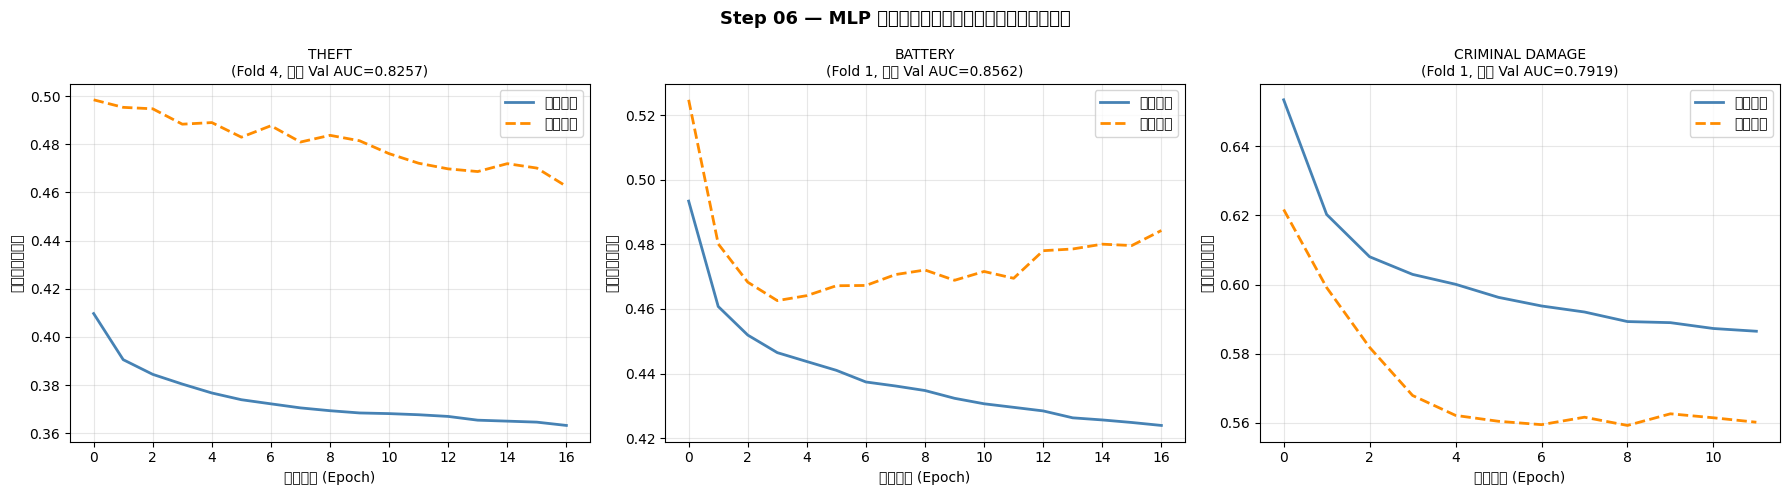

  图片已保存: d:\Trae_Projects\It5006\model_mlp_v2\outputs\06_mlp_loss_curves.png

[5/5] 绘制 CV AUC 柱状图...


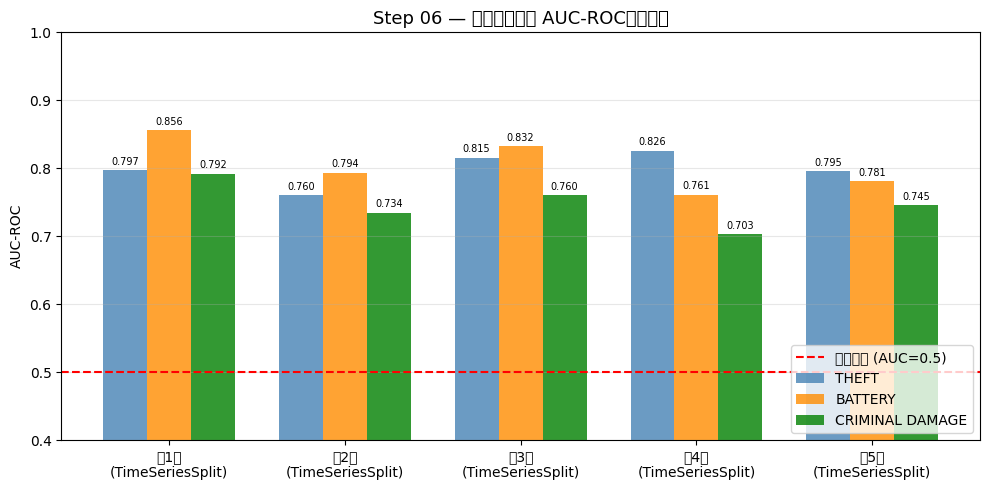

  图片已保存: d:\Trae_Projects\It5006\model_mlp_v2\outputs\06_mlp_cv_auc_bars.png

✓ Step 06 完成

  测试集最终 AUC-ROC:
    THEFT: 0.8102
    BATTERY: 0.8079
    CRIMINAL DAMAGE: 0.7515


In [2]:
# 设置随机种子保证可复现
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)



# ── 模型构建（核心函数，被 step07 导入使用）──────────────────────────────────

def build_mlp(input_dim: int,
              units: tuple = (256, 128, 64),
              dropout: tuple = (0.3, 0.3, 0.2),
              lr: float = 1e-3,
              l2_reg: float = 1e-4) -> keras.Model:
    """
    构建并编译 MLP 二分类模型。

    参数设计说明：
      units   : 三层全连接的神经元数，越大模型越复杂，越容易过拟合
      dropout : 每层后的 Dropout 比例，防止过拟合的关键手段
      lr      : Adam 优化器的学习率，太大震荡，太小收敛慢
      l2_reg  : L2 正则化系数，对大权重进行惩罚

    BatchNormalization 的作用：
      标准化每层的输入分布，加速收敛并减少对初始学习率的敏感性。

    Sigmoid 输出层的作用：
      将网络输出压缩到 [0, 1]，解释为"该(网格,周)发生犯罪的概率"。
    """
    model = keras.Sequential([
        # 第一层：主要特征提取
        layers.Dense(units[0], activation='relu', input_shape=(input_dim,),
                     kernel_regularizer=keras.regularizers.l2(l2_reg)),
        layers.BatchNormalization(),
        layers.Dropout(dropout[0]),

        # 第二层：高阶特征组合
        layers.Dense(units[1], activation='relu',
                     kernel_regularizer=keras.regularizers.l2(l2_reg)),
        layers.BatchNormalization(),
        layers.Dropout(dropout[1]),

        # 第三层：精细化特征
        layers.Dense(units[2], activation='relu'),
        layers.Dropout(dropout[2]),

        # 输出层：预测犯罪发生概率
        layers.Dense(1, activation='sigmoid')
    ], name='crime_mlp')

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='binary_crossentropy',
        metrics=[
            keras.metrics.AUC(name='auc'),
            keras.metrics.Precision(name='precision'),
            keras.metrics.Recall(name='recall'),
        ]
    )
    return model


def get_callbacks(patience_stop: int = 7, patience_lr: int = 3):
    """
    返回训练回调函数列表。

    EarlyStopping：
      当验证集 AUC 在连续 patience_stop 轮内不再提升时，停止训练。
      restore_best_weights=True 确保使用历史最优权重，而非最后一轮的权重。

    ReduceLROnPlateau：
      当 AUC 在 patience_lr 轮内停滞，将学习率减半，
      帮助模型从高原期（plateau）走出。
    """
    return [
        EarlyStopping(monitor='val_auc', patience=patience_stop, mode='max',
                      restore_best_weights=True, verbose=0),
        ReduceLROnPlateau(monitor='val_auc', factor=0.5, patience=patience_lr,
                          mode='max', verbose=0)
    ]


# ── 交叉验证 ──────────────────────────────────────────────────────────────────

def run_mlp_cv(X_train: np.ndarray, y_train_dict: dict,
               top3: list, n_splits: int = N_SPLITS,
               epochs: int = EPOCHS, batch_size: int = BATCH_SIZE) -> tuple:
    """
    对每种犯罪类型运行时序交叉验证。

    返回:
      cv_results : {crime: [fold_metrics_dict, ...]}
      cv_history : {crime: [history_dict, ...]}（纯 Python 字典，可 pickle）
    """
    tscv = TimeSeriesSplit(n_splits=n_splits)
    cv_results = {crime: [] for crime in top3}
    cv_history = {crime: [] for crime in top3}

    for crime in top3:
        print(f'\n{"="*55}')
        print(f'交叉验证: {crime}')
        print(f'{"="*55}')

        y_train = y_train_dict[crime]

        # 计算类别权重（补偿正负样本不平衡）
        n_neg, n_pos = int((y_train == 0).sum()), int((y_train == 1).sum())
        class_weight = {0: 1.0, 1: n_neg / max(n_pos, 1)}
        print(f'  负:正 = {n_neg:,}:{n_pos:,}  →  class_weight[1] = {class_weight[1]:.1f}')

        for fold, (tr_idx, val_idx) in enumerate(tscv.split(X_train)):
            # 每折重新初始化模型（防止折间权重干扰）
            model = build_mlp(X_train.shape[1])

            history = model.fit(
                X_train[tr_idx], y_train[tr_idx],
                validation_data=(X_train[val_idx], y_train[val_idx]),
                epochs=epochs,
                batch_size=batch_size,
                class_weight=class_weight,
                callbacks=get_callbacks(),
                verbose=0
            )

            # 预测验证集
            y_prob = model.predict(X_train[val_idx], verbose=0).ravel()
            y_pred = (y_prob >= 0.5).astype(int)

            fold_metrics = {
                'fold':       fold + 1,
                'precision':  precision_score(y_train[val_idx], y_pred, zero_division=0),
                'recall':     recall_score(y_train[val_idx], y_pred, zero_division=0),
                'f1':         f1_score(y_train[val_idx], y_pred, zero_division=0),
                'auc_roc':    roc_auc_score(y_train[val_idx], y_prob),
                'epochs_run': len(history.history['loss']),
            }
            cv_results[crime].append(fold_metrics)

            # 保存训练历史（转为普通字典，方便 pickle）
            cv_history[crime].append({k: v for k, v in history.history.items()})

            print(f'  Fold {fold+1}: P={fold_metrics["precision"]:.4f}  '
                  f'R={fold_metrics["recall"]:.4f}  '
                  f'F1={fold_metrics["f1"]:.4f}  '
                  f'AUC={fold_metrics["auc_roc"]:.4f}  '
                  f'(epochs={fold_metrics["epochs_run"]})')

        # 打印折均值
        fold_df = pd.DataFrame(cv_results[crime])
        print(f'\n  {n_splits} 折均值 ± 标准差:')
        for m in ['precision', 'recall', 'f1', 'auc_roc']:
            print(f'    {m:12s}: {fold_df[m].mean():.4f} ± {fold_df[m].std():.4f}')

    return cv_results, cv_history


# ── 最终训练与评估 ────────────────────────────────────────────────────────────

def train_final_models(X_train: np.ndarray, y_train_dict: dict,
                       X_test: np.ndarray, y_test_dict: dict,
                       top3: list, models_dir: str,
                       epochs: int = EPOCHS, batch_size: int = BATCH_SIZE) -> tuple:
    """
    在全量训练集上训练最终模型，评估 2025 测试集，并保存模型。

    为什么要在全量训练集上重新训练？
      CV 过程中每折只用部分数据训练，最终模型应利用全部 2015-2024 数据。
      使用 10% 作为 EarlyStopping 的验证集（不用于性能报告）。
    """
    final_metrics = {}
    os.makedirs(models_dir, exist_ok=True)

    for crime in top3:
        print(f'\n  训练最终模型: {crime}')
        y_train = y_train_dict[crime]
        y_test  = y_test_dict[crime]

        n_neg, n_pos = int((y_train == 0).sum()), int((y_train == 1).sum())
        class_weight = {0: 1.0, 1: n_neg / max(n_pos, 1)}

        model = build_mlp(X_train.shape[1])
        model.fit(
            X_train, y_train,
            epochs=epochs,
            batch_size=batch_size,
            class_weight=class_weight,
            validation_split=0.1,   # 保留 10% 供 EarlyStopping 监控
            callbacks=get_callbacks(),
            verbose=0
        )

        # 在 2025 测试集上评估
        y_prob = model.predict(X_test, verbose=0).ravel()
        y_pred = (y_prob >= 0.5).astype(int)

        # 标准格式（step11 读取）
        final_metrics[crime] = {
            'precision': precision_score(y_test, y_pred, zero_division=0),
            'recall':    recall_score(y_test, y_pred, zero_division=0),
            'f1':        f1_score(y_test, y_pred, zero_division=0),
            'auc_roc':   roc_auc_score(y_test, y_prob),
        }

        print(f'    Precision: {final_metrics[crime]["precision"]:.4f}')
        print(f'    Recall:    {final_metrics[crime]["recall"]:.4f}')
        print(f'    F1:        {final_metrics[crime]["f1"]:.4f}')
        print(f'    AUC-ROC:   {final_metrics[crime]["auc_roc"]:.4f}')
        print(f'    分类报告:\n{classification_report(y_test, y_pred, zero_division=0)}')

        # 保存模型（SavedModel 格式，便于跨平台加载）
        save_path = os.path.join(models_dir, crime.replace(' ', '_') + '.keras')
        model.save(save_path)
        print(f'    模型已保存: {save_path}')

    return final_metrics


# ── 可视化 ────────────────────────────────────────────────────────────────────

def plot_loss_curves(cv_history: dict, cv_results: dict, top3: list, out_path: str):
    """
    绘制每种犯罪类型的"最佳折"训练/验证损失曲线。

    最佳折 = CV 中 AUC-ROC 最高的那一折。

    运行后请检查：
      - 验证损失是否在训练损失趋于平稳后也平稳（无过拟合）
      - 是否有明显的"验证损失反弹"（可能需要更强的 Dropout）
      - EarlyStopping 是否在合理的 epoch 数停止（通常 20-40 轮）
    """
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle('Step 06 — MLP 训练损失曲线（每种犯罪类型的最优折）',
                 fontsize=13, fontweight='bold')

    for ax, crime in zip(axes, top3):
        # 找到 AUC 最高的折
        best_fold_idx = max(range(len(cv_results[crime])),
                            key=lambda i: cv_results[crime][i]['auc_roc'])
        hist = cv_history[crime][best_fold_idx]

        ax.plot(hist['loss'],     label='训练损失', linewidth=2, color='steelblue')
        ax.plot(hist['val_loss'], label='验证损失', linewidth=2, linestyle='--', color='darkorange')

        best_auc = cv_results[crime][best_fold_idx]['auc_roc']
        ax.set_title(f'{crime}\n(Fold {best_fold_idx+1}, 最优 Val AUC={best_auc:.4f})',
                     fontsize=10)
        ax.set_xlabel('训练轮次 (Epoch)')
        ax.set_ylabel('二元交叉熵损失')
        ax.legend()
        ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'  图片已保存: {out_path}')


def plot_cv_auc_bars(cv_results: dict, top3: list, out_path: str):
    """
    绘制各折 AUC-ROC 的分组柱状图。

    通过观察不同折之间的 AUC 差异，可以判断模型稳定性：
      - 折间差异小 → 模型稳定，泛化能力强
      - 折间差异大 → 模型对特定时段敏感，可能需要更多数据

    运行后请检查：
      - 所有折的 AUC 是否都显著高于 0.5（随机基线）
      - 最后几折（更接近测试集时间的折）AUC 是否有下降趋势
        （下降意味着近期的犯罪模式与历史有所不同）
    """
    n_splits = len(cv_results[top3[0]])
    x = np.arange(1, n_splits + 1)
    width = 0.25
    colors = ['steelblue', 'darkorange', 'green']

    fig, ax = plt.subplots(figsize=(10, 5))

    for i, (crime, color) in enumerate(zip(top3, colors)):
        aucs = [cv_results[crime][f]['auc_roc'] for f in range(n_splits)]
        bars = ax.bar(x + i * width, aucs, width=width, label=crime,
                      color=color, alpha=0.8)
        # 标注数值
        for bar, auc in zip(bars, aucs):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                    f'{auc:.3f}', ha='center', va='bottom', fontsize=7)

    ax.axhline(0.5, color='red', linestyle='--', linewidth=1.5,
               label='随机基线 (AUC=0.5)')
    ax.set_xticks(x + width)
    ax.set_xticklabels([f'第{i}折\n(TimeSeriesSplit)' for i in range(1, n_splits+1)])
    ax.set_ylabel('AUC-ROC')
    ax.set_ylim(0.4, 1.0)
    ax.set_title('Step 06 — 时序交叉验证 AUC-ROC（各折）', fontsize=13)
    ax.legend(loc='lower right')
    ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'  图片已保存: {out_path}')


# ── 主流程 ────────────────────────────────────────────────────────────────────

def main():
    os.makedirs(OUTPUT_DIR, exist_ok=True)

    print('=' * 60)
    print('Step 06 — MLP 神经网络训练（改进版）')
    print('=' * 60)
    print(f'  关键改进: StratifiedKFold → TimeSeriesSplit（防止时序泄漏）')
    print(f'  模型将保存到磁盘（后续步骤无需重训）')

    # 1. 加载数据
    print('\n[1/5] 加载 Step 04 输出数据...')
    with open(os.path.join(OUTPUT_DIR, '04_X_train.pkl'), 'rb') as f:
        X_train = pickle.load(f)
    with open(os.path.join(OUTPUT_DIR, '04_X_test.pkl'), 'rb') as f:
        X_test = pickle.load(f)
    with open(os.path.join(OUTPUT_DIR, '04_y_train.pkl'), 'rb') as f:
        y_train_dict = pickle.load(f)
    with open(os.path.join(OUTPUT_DIR, '04_y_test.pkl'), 'rb') as f:
        y_test_dict = pickle.load(f)
    with open(os.path.join(OUTPUT_DIR, '01_top3.pkl'), 'rb') as f:
        top3 = pickle.load(f)

    print(f'  X_train: {X_train.shape}, X_test: {X_test.shape}')

    # 打印模型架构（只打印一次）
    print('\n  MLP 模型架构:')
    demo = build_mlp(X_train.shape[1])
    demo.summary()
    del demo

    # 2. 时序交叉验证
    print(f'\n[2/5] 运行时序交叉验证（{N_SPLITS} 折）...')
    cv_results, cv_history = run_mlp_cv(
        X_train, y_train_dict, top3, N_SPLITS, EPOCHS, BATCH_SIZE
    )

    # 3. 最终模型训练
    models_dir = os.path.join(OUTPUT_DIR, '06_mlp_final_models')
    print(f'\n[3/5] 在全量训练集上训练最终模型...')
    final_metrics = train_final_models(
        X_train, y_train_dict, X_test, y_test_dict,
        top3, models_dir, EPOCHS, BATCH_SIZE
    )

    # 4. 保存结果
    print('\n保存结果...')
    with open(os.path.join(OUTPUT_DIR, '06_mlp_cv_results.pkl'), 'wb') as f:
        pickle.dump(cv_results, f)
    with open(os.path.join(OUTPUT_DIR, '06_mlp_cv_history.pkl'), 'wb') as f:
        pickle.dump(cv_history, f)
    # ★ 标准输出格式
    with open(os.path.join(OUTPUT_DIR, '06_mlp_metrics.pkl'), 'wb') as f:
        pickle.dump(final_metrics, f)
    print('  已保存: 06_mlp_cv_results.pkl, 06_mlp_cv_history.pkl, 06_mlp_metrics.pkl')

    # 5. 可视化
    print('\n[4/5] 绘制损失曲线...')
    plot_loss_curves(cv_history, cv_results, top3,
                     out_path=os.path.join(OUTPUT_DIR, '06_mlp_loss_curves.png'))

    print('\n[5/5] 绘制 CV AUC 柱状图...')
    plot_cv_auc_bars(cv_results, top3,
                     out_path=os.path.join(OUTPUT_DIR, '06_mlp_cv_auc_bars.png'))

    print('\n✓ Step 06 完成')
    print('\n  测试集最终 AUC-ROC:')
    for crime in top3:
        print(f'    {crime}: {final_metrics[crime]["auc_roc"]:.4f}')


main()

## Step 07 — Optuna 超参数调优（可选，周震宦负责）

> **可选步骤** — Optuna 调优约需 1-2 小时，跳过不影响后续步骤。

In [ ]:
try:
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    OPTUNA_AVAILABLE = True
except ImportError:
    OPTUNA_AVAILABLE = False
    print('⚠️ Optuna 未安装，Step 07 将跳过。pip install optuna')

# 从 step06 导入 build_mlp（保持模型定义一致）

# ── 调优配置 ──────────────────────────────────────────────────────────────────
N_TRIALS    = 50   # 每种犯罪类型的 Optuna 搜索次数（时间充裕可改为 100）
N_CV_SPLITS = 3    # Trial 内部 CV 折数（用 3 折快速评估，全量训练时用最优参数）
TUNE_EPOCHS = 30   # Trial 内部训练轮次（比完整训练少，加快搜索速度）


def make_objective(X_train: np.ndarray, y_train: np.ndarray,
                   input_dim: int, n_cv_splits: int = N_CV_SPLITS):
    """
    创建 Optuna 目标函数（工厂函数）。

    Optuna 工作原理：
      1. 对每次 trial，Optuna 从搜索空间采样一组超参数
      2. 调用此目标函数，用该组参数训练模型并返回验证 AUC
      3. Optuna 根据历史结果（贝叶斯优化）选择下一组更有希望的参数
      4. 重复 N_TRIALS 次，保留最优参数

    objective 函数的返回值是验证 AUC（越高越好，Optuna 会最大化它）。
    """
    def objective(trial):
        # ── 从搜索空间采样超参数 ────────────────────────────────────────────
        units = (
            trial.suggest_categorical('units_l1', [64, 128, 256, 512]),
            trial.suggest_categorical('units_l2', [32, 64, 128, 256]),
            trial.suggest_categorical('units_l3', [16, 32, 64, 128]),
        )
        dropout = (
            trial.suggest_float('dropout_1', 0.1, 0.5),
            trial.suggest_float('dropout_2', 0.1, 0.5),
            trial.suggest_float('dropout_3', 0.1, 0.4),
        )
        lr         = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
        batch_size = trial.suggest_categorical('batch_size', [256, 512, 1024])

        # ── 快速 CV 评估 ─────────────────────────────────────────────────────
        tscv = TimeSeriesSplit(n_splits=n_cv_splits)
        fold_aucs = []

        n_neg = int((y_train == 0).sum())
        n_pos = int((y_train == 1).sum())
        class_weight = {0: 1.0, 1: n_neg / max(n_pos, 1)}

        for tr_idx, val_idx in tscv.split(X_train):
            # 使用 trial 采样的参数构建模型
            model = build_mlp(input_dim, units=units, dropout=dropout,
                               lr=lr, l2_reg=1e-4)
            model.fit(
                X_train[tr_idx], y_train[tr_idx],
                validation_data=(X_train[val_idx], y_train[val_idx]),
                epochs=TUNE_EPOCHS,
                batch_size=batch_size,
                class_weight=class_weight,
                callbacks=[
                    tf.keras.callbacks.EarlyStopping(
                        monitor='val_auc', patience=5, mode='max',
                        restore_best_weights=True, verbose=0
                    )
                ],
                verbose=0
            )
            y_prob = model.predict(X_train[val_idx], verbose=0).ravel()
            fold_aucs.append(roc_auc_score(y_train[val_idx], y_prob))

            # 释放显存（避免多次 trial 后内存溢出）
            del model
            tf.keras.backend.clear_session()

        return np.mean(fold_aucs)  # Optuna 最大化此值

    return objective


def tune_crime(crime: str, X_train: np.ndarray, y_train: np.ndarray,
               input_dim: int, n_trials: int = N_TRIALS) -> tuple:
    """
    对单个犯罪类型运行 Optuna 调优。

    返回:
      study      : Optuna Study 对象（含所有 trial 历史）
      best_params: 最优超参数字典
    """
    print(f'\n  调优: {crime}（{n_trials} 次 trial）')

    study = optuna.create_study(
        direction='maximize',
        sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED)  # 贝叶斯优化采样器
    )

    study.optimize(
        make_objective(X_train, y_train, input_dim),
        n_trials=n_trials,
        show_progress_bar=True
    )

    best_params = study.best_params
    best_auc    = study.best_value
    print(f'  最优 AUC: {best_auc:.4f}')
    print(f'  最优参数: {best_params}')

    return study, best_params


def train_with_best_params(crime: str, best_params: dict,
                           X_train: np.ndarray, y_train: np.ndarray,
                           X_test: np.ndarray, y_test: np.ndarray,
                           input_dim: int, save_dir: str) -> dict:
    """
    用最优参数在全量训练集上重新训练，并评估测试集。

    返回标准格式的指标字典（供 step11 使用）。
    """
    units = (
        best_params['units_l1'],
        best_params['units_l2'],
        best_params['units_l3'],
    )
    dropout = (
        best_params['dropout_1'],
        best_params['dropout_2'],
        best_params['dropout_3'],
    )

    n_neg = int((y_train == 0).sum())
    n_pos = int((y_train == 1).sum())
    class_weight = {0: 1.0, 1: n_neg / max(n_pos, 1)}

    model = build_mlp(
        input_dim,
        units=units,
        dropout=dropout,
        lr=best_params['lr'],
        l2_reg=1e-4
    )
    model.fit(
        X_train, y_train,
        epochs=EPOCHS,
        batch_size=best_params['batch_size'],
        class_weight=class_weight,
        validation_split=0.1,
        callbacks=get_callbacks(),
        verbose=0
    )

    y_prob = model.predict(X_test, verbose=0).ravel()
    y_pred = (y_prob >= 0.5).astype(int)

    metrics = {
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall':    recall_score(y_test, y_pred, zero_division=0),
        'f1':        f1_score(y_test, y_pred, zero_division=0),
        'auc_roc':   roc_auc_score(y_test, y_prob),
    }

    print(f'  [{crime}] 调优后测试集 AUC: {metrics["auc_roc"]:.4f}')

    # 保存模型
    crime_save_dir = os.path.join(save_dir, crime.replace(' ', '_') + '.keras')
    model.save(crime_save_dir)
    print(f'  调优模型已保存: {crime_save_dir}')

    del model
    tf.keras.backend.clear_session()

    return metrics


def plot_optuna_history(studies: dict, top3: list, out_path: str):
    """
    绘制每种犯罪类型的 Optuna 优化历史曲线。

    每个点代表一次 trial 的验证 AUC，折线跟踪当前最优值的演化。

    运行后请检查：
      - 最优值是否在前 20-30 次 trial 就基本收敛（说明搜索空间合理）
      - 如果直到第 50 次还在明显上升，建议增加 N_TRIALS
    """
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle('Step 07 — Optuna 超参数调优历史（三种犯罪类型）',
                 fontsize=13, fontweight='bold')

    for ax, crime in zip(axes, top3):
        study = studies[crime]
        trials = study.trials

        trial_nums = [t.number for t in trials if t.value is not None]
        aucs       = [t.value  for t in trials if t.value is not None]

        # 计算累积最优值
        best_so_far = []
        current_best = -np.inf
        for auc in aucs:
            current_best = max(current_best, auc)
            best_so_far.append(current_best)

        ax.scatter(trial_nums, aucs, alpha=0.4, s=20, color='steelblue', label='各 trial AUC')
        ax.plot(trial_nums, best_so_far, color='red', linewidth=2, label='当前最优 AUC')
        ax.axhline(0.5, color='gray', linestyle='--', linewidth=1, alpha=0.7)

        ax.set_xlabel('Trial 编号')
        ax.set_ylabel('验证集 AUC-ROC')
        ax.set_title(f'{crime}\n最优: {study.best_value:.4f}', fontsize=11)
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'  图片已保存: {out_path}')


# ── 主流程 ────────────────────────────────────────────────────────────────────

def main():
    os.makedirs(OUTPUT_DIR, exist_ok=True)

    print('=' * 60)
    print('Step 07 — Optuna 超参数调优（周震寰）')
    print('=' * 60)
    print(f'  每种犯罪类型: {N_TRIALS} 次 trial × {N_CV_SPLITS} 折 CV')

    # 1. 加载数据
    print('\n[1/4] 加载 Step 04 输出数据...')
    with open(os.path.join(OUTPUT_DIR, '04_X_train.pkl'), 'rb') as f:
        X_train = pickle.load(f)
    with open(os.path.join(OUTPUT_DIR, '04_X_test.pkl'), 'rb') as f:
        X_test = pickle.load(f)
    with open(os.path.join(OUTPUT_DIR, '04_y_train.pkl'), 'rb') as f:
        y_train_dict = pickle.load(f)
    with open(os.path.join(OUTPUT_DIR, '04_y_test.pkl'), 'rb') as f:
        y_test_dict = pickle.load(f)
    with open(os.path.join(OUTPUT_DIR, '01_top3.pkl'), 'rb') as f:
        top3 = pickle.load(f)

    input_dim = X_train.shape[1]
    print(f'  特征维度: {input_dim}')

    # 2. 对每种犯罪类型进行超参数调优
    print('\n[2/4] 开始 Optuna 调优（共 3 × {N_TRIALS} 次 trial）...')
    studies    = {}
    best_params_all = {}

    for crime in top3:
        study, best_params = tune_crime(
            crime, X_train, y_train_dict[crime], input_dim, N_TRIALS
        )
        studies[crime]         = study
        best_params_all[crime] = best_params

    # 3. 用最优参数训练最终模型并评估
    print('\n[3/4] 用最优参数训练最终模型并评估测试集...')
    tuned_metrics_dir = os.path.join(OUTPUT_DIR, '07_tuned_mlp_models')
    os.makedirs(tuned_metrics_dir, exist_ok=True)

    tuned_metrics = {}
    for crime in top3:
        metrics = train_with_best_params(
            crime, best_params_all[crime],
            X_train, y_train_dict[crime],
            X_test,  y_test_dict[crime],
            input_dim, tuned_metrics_dir
        )
        tuned_metrics[crime] = metrics

    # 4. 保存结果
    print('\n保存结果...')
    with open(os.path.join(OUTPUT_DIR, '07_best_params.pkl'), 'wb') as f:
        pickle.dump(best_params_all, f)
    # ★ 标准输出格式
    with open(os.path.join(OUTPUT_DIR, '07_tuned_metrics.pkl'), 'wb') as f:
        pickle.dump(tuned_metrics, f)
    print('  已保存: 07_best_params.pkl, 07_tuned_metrics.pkl')

    # 5. 可视化
    print('\n[4/4] 绘制 Optuna 优化历史...')
    plot_optuna_history(
        studies, top3,
        out_path=os.path.join(OUTPUT_DIR, '07_optuna_history.png')
    )

    # 打印汇总
    print('\n✓ Step 07 完成 — 超参数调优结果汇总:')
    print(f'\n  {"犯罪类型":<20} {"AUC(默认)":<12} {"AUC(调优)":<12} {"提升":<8}')
    print('  ' + '-' * 55)

    # 对比默认参数和调优后的 AUC
    default_metrics_path = os.path.join(OUTPUT_DIR, '06_mlp_metrics.pkl')
    if os.path.exists(default_metrics_path):
        with open(default_metrics_path, 'rb') as f:
            default_metrics = pickle.load(f)
        for crime in top3:
            default_auc = default_metrics[crime]['auc_roc']
            tuned_auc   = tuned_metrics[crime]['auc_roc']
            delta = tuned_auc - default_auc
            sign  = '+' if delta >= 0 else ''
            print(f'  {crime:<20} {default_auc:<12.4f} {tuned_auc:<12.4f} {sign}{delta:.4f}')
    else:
        for crime in top3:
            print(f'  {crime}: AUC = {tuned_metrics[crime]["auc_roc"]:.4f}')

    print('\n  最优超参数详情:')
    for crime in top3:
        print(f'\n  [{crime}]')
        for k, v in best_params_all[crime].items():
            print(f'    {k}: {v}')


if OPTUNA_AVAILABLE:
    main()
else:
    print('Step 07 跳过（Optuna 未安装）')

## Step 08 — 统一模型评估与可视化

In [ ]:
def load_all_models(top3: list) -> dict:
    """
    加载所有可用模型。

    返回字典: {model_name: {crime: model_or_predictor}}
    其中 predictor 是一个统一接口: predict_proba(X) → 概率数组

    如果 step07 未运行（无调优模型），自动跳过。
    """
    import tensorflow as tf

    models = {}

    # ── LR 基线 ────────────────────────────────────────────────────────────────
    lr_path = os.path.join(OUTPUT_DIR, '05_lr_final_models.pkl')
    if os.path.exists(lr_path):
        with open(lr_path, 'rb') as f:
            lr_models = pickle.load(f)
        # 包装为统一接口：输入 X，输出 1D 概率数组
        models['LR-基线'] = {
            crime: (lambda m: lambda X: m.predict_proba(X)[:, 1])(lr_models[crime])
            for crime in top3 if crime in lr_models
        }
        print('  已加载: LR 基线模型')
    else:
        print('  警告: 05_lr_final_models.pkl 不存在，请先运行 step05')

    # ── MLP 默认参数 ───────────────────────────────────────────────────────────
    mlp_dir = os.path.join(OUTPUT_DIR, '06_mlp_final_models')
    if os.path.exists(mlp_dir):
        mlp_models = {}
        for crime in top3:
            crime_dir = os.path.join(mlp_dir, crime.replace(' ', '_') + '.keras')
            if os.path.exists(crime_dir):
                m = tf.keras.models.load_model(crime_dir)
                mlp_models[crime] = (lambda mo: lambda X: mo.predict(X, verbose=0).ravel())(m)
        models['MLP-默认'] = mlp_models
        print('  已加载: MLP 默认参数模型')
    else:
        print('  警告: 06_mlp_final_models/ 不存在，请先运行 step06')

    # ── MLP 调优参数（可选）────────────────────────────────────────────────────
    tuned_dir = os.path.join(OUTPUT_DIR, '07_tuned_mlp_models')
    if os.path.exists(tuned_dir):
        tuned_models = {}
        for crime in top3:
            crime_dir = os.path.join(tuned_dir, crime.replace(' ', '_') + '.keras')
            if os.path.exists(crime_dir):
                m = tf.keras.models.load_model(crime_dir)
                tuned_models[crime] = (lambda mo: lambda X: mo.predict(X, verbose=0).ravel())(m)
        if tuned_models:
            models['MLP-调优'] = tuned_models
            print('  已加载: MLP 调优参数模型')
    else:
        print('  信息: 07_tuned_mlp_models/ 不存在，跳过调优模型（可先运行 step07）')

    return models


def compute_all_metrics(models: dict, X_test: np.ndarray,
                         y_test_dict: dict, top3: list) -> pd.DataFrame:
    """
    计算所有模型在测试集上的完整指标，返回 DataFrame。

    输出格式（每行一个 model × crime 组合）：
      model_name | crime_type | precision | recall | f1 | auc_roc
    """
    rows = []
    for model_name, crime_models in models.items():
        for crime in top3:
            if crime not in crime_models:
                continue
            predict_fn = crime_models[crime]
            y_test = y_test_dict[crime]
            y_prob = predict_fn(X_test)
            y_pred = (y_prob >= 0.5).astype(int)

            rows.append({
                'model_name': model_name,
                'crime_type': crime,
                'precision':  round(precision_score(y_test, y_pred, zero_division=0), 4),
                'recall':     round(recall_score(y_test, y_pred, zero_division=0), 4),
                'f1':         round(f1_score(y_test, y_pred, zero_division=0), 4),
                'auc_roc':    round(roc_auc_score(y_test, y_prob), 4),
            })

    return pd.DataFrame(rows)


def plot_roc_curves(models: dict, X_test: np.ndarray,
                    y_test_dict: dict, top3: list, out_path: str):
    """
    绘制所有模型 × 所有犯罪类型的 ROC 曲线对比图。

    布局：1行 × 3列，每列一种犯罪类型，不同模型用不同线型区分：
      - LR 基线: 点划线 (-.)
      - MLP 默认: 实线 (-)
      - MLP 调优: 虚线 (--)

    运行后请检查：
      - MLP 的 ROC 曲线是否整体在 LR 曲线的"左上方"（AUC 更高）
      - 如果 LR 和 MLP 的曲线几乎重叠，说明 MLP 没有发挥非线性优势
    """
    line_styles = {
        'LR-基线':  ('-.',  1.5),
        'MLP-默认': ('-',   2.5),
        'MLP-调优': ('--',  2.0),
    }
    colors = ['steelblue', 'darkorange', 'green']

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle('Step 08 — ROC 曲线对比（2025 测试集）', fontsize=14, fontweight='bold')

    for ax, crime, color in zip(axes, top3, colors):
        y_test = y_test_dict[crime]

        for model_name, crime_models in models.items():
            if crime not in crime_models:
                continue
            y_prob = crime_models[crime](X_test)
            fpr, tpr, _ = roc_curve(y_test, y_prob)
            auc = roc_auc_score(y_test, y_prob)

            ls, lw = line_styles.get(model_name, ('-', 1.5))
            ax.plot(fpr, tpr, linestyle=ls, linewidth=lw,
                    label=f'{model_name} (AUC={auc:.4f})', color=color,
                    alpha=0.9 if model_name == 'MLP-调优' else 0.7)

        ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='随机基线')
        ax.set_xlabel('假正率 (FPR)')
        ax.set_ylabel('真正率 (TPR)')
        ax.set_title(crime, fontsize=11)
        ax.legend(loc='lower right', fontsize=8)
        ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'  图片已保存: {out_path}')


def plot_confusion_matrices(models: dict, X_test: np.ndarray,
                             y_test_dict: dict, top3: list, out_path: str):
    """
    绘制所有模型 × 犯罪类型的混淆矩阵网格。

    布局：行 = 模型，列 = 犯罪类型
    """
    n_models = len(models)
    n_crimes = len(top3)

    fig, axes = plt.subplots(n_models, n_crimes,
                              figsize=(5 * n_crimes, 4 * n_models))
    if n_models == 1:
        axes = axes[np.newaxis, :]
    fig.suptitle('Step 08 — 混淆矩阵（2025 测试集，阈值=0.5）',
                 fontsize=13, fontweight='bold')

    for row_idx, (model_name, crime_models) in enumerate(models.items()):
        for col_idx, crime in enumerate(top3):
            ax = axes[row_idx, col_idx]
            if crime not in crime_models:
                ax.axis('off')
                continue

            y_test = y_test_dict[crime]
            y_prob = crime_models[crime](X_test)
            y_pred = (y_prob >= 0.5).astype(int)
            cm = confusion_matrix(y_test, y_pred)

            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                        xticklabels=['预测:0', '预测:1'],
                        yticklabels=['实际:0', '实际:1'],
                        annot_kws={'size': 11})

            # 行标题（模型名）
            if col_idx == 0:
                ax.set_ylabel(model_name, fontsize=11, fontweight='bold')
            # 列标题（犯罪类型）
            if row_idx == 0:
                ax.set_title(crime, fontsize=11)

            # 标注召回率（减少漏报的关键指标）
            if cm.shape == (2, 2) and cm[1].sum() > 0:
                recall = cm[1, 1] / cm[1].sum() * 100
                ax.set_xlabel(f'Recall={recall:.1f}%', fontsize=9)

    plt.tight_layout()
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'  图片已保存: {out_path}')


# ── 主流程 ────────────────────────────────────────────────────────────────────

def main():
    os.makedirs(OUTPUT_DIR, exist_ok=True)

    print('=' * 60)
    print('Step 08 — 统一评估与可视化')
    print('=' * 60)

    # 1. 加载数据
    print('\n[1/4] 加载测试数据...')
    with open(os.path.join(OUTPUT_DIR, '04_X_test.pkl'), 'rb') as f:
        X_test = pickle.load(f)
    with open(os.path.join(OUTPUT_DIR, '04_y_test.pkl'), 'rb') as f:
        y_test_dict = pickle.load(f)
    with open(os.path.join(OUTPUT_DIR, '01_top3.pkl'), 'rb') as f:
        top3 = pickle.load(f)

    # 2. 加载所有模型
    print('\n[2/4] 加载所有模型...')
    models = load_all_models(top3)
    print(f'  已加载模型: {list(models.keys())}')

    # 3. 计算指标
    print('\n[3/4] 计算所有模型的测试集指标...')
    metrics_df = compute_all_metrics(models, X_test, y_test_dict, top3)

    print('\n  指标汇总表:')
    print(metrics_df.to_string(index=False))

    # 保存 CSV（供 step11 读取）
    csv_path = os.path.join(OUTPUT_DIR, '08_metrics_summary.csv')
    metrics_df.to_csv(csv_path, index=False)
    print(f'\n  已保存 CSV: {csv_path}')

    # 4. 可视化
    print('\n[4/4] 生成可视化图...')
    plot_roc_curves(models, X_test, y_test_dict, top3,
                    out_path=os.path.join(OUTPUT_DIR, '08_roc_curves.png'))

    plot_confusion_matrices(models, X_test, y_test_dict, top3,
                            out_path=os.path.join(OUTPUT_DIR, '08_confusion_matrices.png'))

    print('\n✓ Step 08 完成')
    # 打印每种犯罪类型最高 AUC 的模型
    for crime in top3:
        best = metrics_df[metrics_df['crime_type'] == crime].nlargest(1, 'auc_roc')
        if not best.empty:
            row = best.iloc[0]
            print(f'  {crime}: 最优模型={row["model_name"]}, AUC={row["auc_roc"]:.4f}')


main()

## Step 09 — 置换特征重要性分析

In [ ]:
np.random.seed(RANDOM_SEED)


def get_temporal_val_set(X_train: np.ndarray, y_train: np.ndarray,
                          val_fraction: float = 0.15) -> tuple:
    """
    取训练集时间尾部的 val_fraction 比例作为验证集。

    关键点：X_train 中的数据已按 (grid_id, year_week) 排序，
    因此末尾的行自然对应于最近的时间段（2023-2024年）。
    取末尾 15% 等价于"用 2023-2024 数据验证特征重要性"，
    代表模型在接近测试集时间段的实际表现。

    为什么是 15% 而不是原版的 10%？
      15% 提供更稳定的 AUC 估计（样本量更大），
      同时仍然专注于最近时期的数据。
    """
    n_val = int(len(X_train) * val_fraction)
    X_val = X_train[-n_val:]
    y_val = y_train[-n_val:]
    print(f'  验证集大小: {len(X_val):,} 行（训练集末尾 {val_fraction*100:.0f}%）')
    return X_val, y_val


def compute_permutation_importance(model_predict_fn,
                                    X_val: np.ndarray,
                                    y_val: np.ndarray,
                                    feature_cols: list,
                                    n_repeats: int = 5) -> pd.Series:
    """
    手动计算置换特征重要性。

    n_repeats 次重复的目的：
      单次随机打乱可能恰好产生幸运或不幸的排列，
      多次重复取均值可以获得更稳健的重要性估计。

    对于每个特征 j：
      importance[j] = baseline_auc - mean(打乱第j列后的 AUC，重复 n_repeats 次)

    正值 → 打乱该特征使 AUC 下降 → 该特征重要
    负值 → 打乱该特征反而使 AUC 微升 → 该特征可能引入噪声（极少见）
    """
    baseline_auc = roc_auc_score(y_val, model_predict_fn(X_val))
    print(f'  基准 AUC（未打乱）: {baseline_auc:.4f}')

    importances = []
    n_features = len(feature_cols)

    for j, feat_name in enumerate(feature_cols):
        if (j + 1) % 10 == 0 or j == n_features - 1:
            print(f'  进度: {j+1}/{n_features} 个特征...', end='\r')

        drop_sum = 0.0
        for _ in range(n_repeats):
            X_perm = X_val.copy()
            # 随机打乱第 j 列（破坏该特征与标签的相关性）
            perm_idx = np.random.permutation(len(X_perm))
            X_perm[:, j] = X_perm[perm_idx, j]

            perm_auc = roc_auc_score(y_val, model_predict_fn(X_perm))
            drop_sum += baseline_auc - perm_auc

        importances.append(drop_sum / n_repeats)

    print()  # 换行
    return pd.Series(importances, index=feature_cols)


def plot_feature_importance(perm_results: dict, top3: list, out_path: str):
    """
    绘制三种犯罪类型的 Top20 特征重要性水平柱状图。

    颜色区分：
      红色  → 正重要性（打乱会降低 AUC，特征有用）
      蓝色  → 负重要性（极少出现，可能是噪声特征）

    运行后请检查：
      - 是否是滞后特征（lag_1w, lag_52w）主导重要性
        （这符合预期：短期自回归和年度季节性是犯罪预测的主要驱动因素）
      - grid_lat/grid_lon 的排名（地理位置的影响力）
      - 不同犯罪类型的特征重要性是否有差异
        （如 THEFT 可能更受时间季节性影响，BATTERY 更受社区特征影响）
    """
    fig, axes = plt.subplots(1, 3, figsize=(18, 8))
    fig.suptitle('Step 09 — MLP 置换特征重要性分析（AUC 下降量，Top20）',
                 fontsize=13, fontweight='bold')

    for ax, crime in zip(axes, top3):
        imp = perm_results[crime].sort_values(ascending=False).head(20)

        # 颜色区分正负重要性
        colors = ['#e74c3c' if v >= 0 else '#3498db' for v in imp.values]

        # 倒序显示（最重要的在最上方）
        ax.barh(range(len(imp)), imp.values[::-1], color=colors[::-1], alpha=0.85)
        ax.set_yticks(range(len(imp)))
        ax.set_yticklabels(imp.index[::-1], fontsize=8)
        ax.set_title(f'{crime}', fontsize=11)
        ax.set_xlabel('平均 AUC 下降量\n（正值=特征重要，打乱会使 AUC 降低）', fontsize=9)
        ax.axvline(0, color='black', linewidth=0.8, linestyle='-')
        ax.grid(axis='x', alpha=0.3)

        # 标注 Top3 特征的数值
        for i, (feat, val) in enumerate(zip(imp.index[::-1][:3],
                                             imp.values[::-1][:3])):
            ax.text(val + 0.0002, i, f'{val:.4f}', va='center', fontsize=7, color='darkred')

    plt.tight_layout()
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'  图片已保存: {out_path}')


# ── 主流程 ────────────────────────────────────────────────────────────────────

def main():
    os.makedirs(OUTPUT_DIR, exist_ok=True)

    print('=' * 60)
    print('Step 09 — 置换特征重要性分析')
    print('=' * 60)
    print('  改进: 验证集取训练集时间尾部15%（比原版10%更稳定）')

    # 1. 加载数据
    print('\n[1/3] 加载数据和模型...')
    with open(os.path.join(OUTPUT_DIR, '04_X_train.pkl'), 'rb') as f:
        X_train = pickle.load(f)
    with open(os.path.join(OUTPUT_DIR, '04_y_train.pkl'), 'rb') as f:
        y_train_dict = pickle.load(f)
    with open(os.path.join(OUTPUT_DIR, '03_feature_cols.pkl'), 'rb') as f:
        feature_cols = pickle.load(f)
    with open(os.path.join(OUTPUT_DIR, '01_top3.pkl'), 'rb') as f:
        top3 = pickle.load(f)

    # 加载 MLP 最终模型
    mlp_dir = os.path.join(OUTPUT_DIR, '06_mlp_final_models')
    final_models = {}
    for crime in top3:
        crime_dir = os.path.join(mlp_dir, crime.replace(' ', '_') + '.keras')
        if os.path.exists(crime_dir):
            m = tf.keras.models.load_model(crime_dir)
            # 包装为预测函数
            final_models[crime] = (lambda mo: lambda X: mo.predict(X, verbose=0).ravel())(m)
            print(f'  已加载 {crime} 模型')
        else:
            print(f'  警告: {crime_dir} 不存在，请先运行 step06')

    if not final_models:
        print('  错误: 没有可用的 MLP 模型，退出。')
        return

    # 2. 计算置换重要性
    print('\n[2/3] 计算置换特征重要性（每个特征重复 5 次）...')
    perm_results = {}

    for crime in top3:
        if crime not in final_models:
            continue
        print(f'\n  处理: {crime}')

        X_val, y_val = get_temporal_val_set(X_train, y_train_dict[crime], val_fraction=0.15)
        imp_series = compute_permutation_importance(
            final_models[crime], X_val, y_val, feature_cols, n_repeats=5
        )
        perm_results[crime] = imp_series

        # 打印 Top5 重要特征
        top5 = imp_series.nlargest(5)
        print(f'  Top5 重要特征:')
        for feat, val in top5.items():
            print(f'    {feat}: {val:.4f}')

    # 3. 保存结果
    print('\n保存结果...')
    with open(os.path.join(OUTPUT_DIR, '09_permutation_importance.pkl'), 'wb') as f:
        pickle.dump(perm_results, f)
    print('  已保存: 09_permutation_importance.pkl')

    # 4. 可视化
    print('\n[3/3] 绘制特征重要性图...')
    plot_feature_importance(
        perm_results, top3,
        out_path=os.path.join(OUTPUT_DIR, '09_feature_importance.png')
    )

    print('\n✓ Step 09 完成')
    print('\n  各犯罪类型最重要的特征:')
    for crime in top3:
        if crime in perm_results:
            top1 = perm_results[crime].idxmax()
            print(f'    {crime}: {top1} (AUC下降 {perm_results[crime].max():.4f})')


main()

## Step 10 — 网格分辨率敏感性分析（1km vs 500m）

In [ ]:
# 复用已定义的函数（避免重复代码）

np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

# ── 待对比的分辨率列表 ────────────────────────────────────────────────────────
# 可扩展：如 [0.01, 0.005, 0.0025] 对比 1km、500m、250m
RESOLUTIONS = [0.01, 0.005]  # 单位: 度（°）

# 各分辨率对应的活跃网格阈值（500m 格更稀疏，适当降低阈值）
ACTIVITY_THRESHOLDS = {0.01: 50, 0.005: 20}

# 快速训练配置（不做完整 50 epoch，加快对比实验速度）
SENSITIVITY_EPOCHS = 30
SENSITIVITY_BATCH  = 512


def run_pipeline_for_resolution(df_train: pd.DataFrame, df_test: pd.DataFrame,
                                  top3: list, res: float,
                                  activity_threshold: int,
                                  epochs: int = SENSITIVITY_EPOCHS,
                                  batch_size: int = SENSITIVITY_BATCH) -> dict:
    """
    对给定网格分辨率运行完整的特征工程 + 训练 + 评估流水线。

    设计原则：复用 step02/03/06 中已定义的函数，不重复代码逻辑。
    这就是为什么 step02/03 将函数定义为可导入的独立函数。

    返回:
      {crime: {'precision': ..., 'recall': ..., 'f1': ..., 'auc_roc': ...,
               'n_active_grids': ..., 'n_train_rows': ...}}
    """
    print(f'\n  ── 分辨率: {res}° ({res*111:.1f}km × {res*111:.1f}km) ──')

    # Step A: 网格划分
    d_tr = add_grid_columns(df_train.copy(), res=res)
    d_te = add_grid_columns(df_test.copy(),  res=res)

    # Step B: 活跃网格过滤（只用训练数据决定）
    active = filter_active_grids(d_tr, threshold=activity_threshold)
    d_tr = d_tr[d_tr['grid_id'].isin(active)].copy()
    d_te = d_te[d_te['grid_id'].isin(active)].copy()
    n_active = len(active)

    # Step C: 时序特征
    d_tr = add_temporal_features(d_tr)
    d_te = add_temporal_features(d_te)

    # Step D: 周聚合（合并训练+测试，保证跨年滞后特征连续）
    d_all = pd.concat([d_tr, d_te], ignore_index=True)
    agg = build_weekly_agg(d_all, top3)

    # Step E: 滞后特征
    agg = add_lag_features(agg, top3, LAG_WEEKS, ROLLING_WINDOWS)

    # Step F: 空间上下文
    agg = add_spatial_context(agg, res=res)

    # Step G: 标签
    for crime in top3:
        agg[f'label_{crime}'] = (agg[f'count_{crime}'] > 0).astype(int)

    # Step H: 特征列 + 分割
    feature_cols = build_feature_cols(top3)
    agg_clean = agg.dropna(subset=feature_cols).copy()
    tr_m = agg_clean['iso_year'].between(2015, 2024)
    te_m = agg_clean['iso_year'] == 2025

    X_tr = agg_clean.loc[tr_m, feature_cols].values
    X_te = agg_clean.loc[te_m, feature_cols].values

    # Step I: 标准化（仅在训练集上 fit）
    sc = StandardScaler()
    X_tr = sc.fit_transform(X_tr)
    X_te = sc.transform(X_te)

    n_train_rows = int(tr_m.sum())
    print(f'    活跃网格: {n_active:,} | 训练样本: {n_train_rows:,} | 测试样本: {int(te_m.sum()):,}')

    # Step J: 训练 MLP 并评估（每种犯罪类型独立）
    results = {}
    for crime in top3:
        y_tr = agg_clean.loc[tr_m, f'label_{crime}'].values
        y_te = agg_clean.loc[te_m, f'label_{crime}'].values

        n_neg = int((y_tr == 0).sum())
        n_pos = int((y_tr == 1).sum())
        if n_pos == 0:
            results[crime] = {'precision': 0, 'recall': 0, 'f1': 0,
                               'auc_roc': 0.5, 'n_active_grids': n_active,
                               'n_train_rows': n_train_rows}
            continue

        class_weight = {0: 1.0, 1: n_neg / n_pos}
        model = build_mlp(X_tr.shape[1])
        model.fit(
            X_tr, y_tr,
            epochs=epochs,
            batch_size=batch_size,
            class_weight=class_weight,
            validation_split=0.1,
            callbacks=[
                tf.keras.callbacks.EarlyStopping(
                    monitor='val_auc', patience=5, mode='max',
                    restore_best_weights=True, verbose=0
                )
            ],
            verbose=0
        )

        y_prob = model.predict(X_te, verbose=0).ravel()
        y_pred = (y_prob >= 0.5).astype(int)

        results[crime] = {
            'precision':      precision_score(y_te, y_pred, zero_division=0),
            'recall':         recall_score(y_te, y_pred, zero_division=0),
            'f1':             f1_score(y_te, y_pred, zero_division=0),
            'auc_roc':        roc_auc_score(y_te, y_prob) if len(np.unique(y_te)) > 1 else 0.5,
            'n_active_grids': n_active,
            'n_train_rows':   n_train_rows,
        }
        print(f'    {crime}: AUC={results[crime]["auc_roc"]:.4f}, '
              f'F1={results[crime]["f1"]:.4f}')

        del model
        tf.keras.backend.clear_session()

    return results


def plot_sensitivity_comparison(all_results: dict, top3: list, out_path: str):
    """
    绘制不同分辨率的对比可视化。

    布局（2行 × 3列）：
      上行: AUC-ROC 对比（每种犯罪类型一列）
      下行: F1-Score 对比

    运行后请检查：
      - 1km 的 AUC 是否普遍高于 500m（如果不是，可能数据量充足时 500m 也很好）
      - 两种分辨率的活跃网格数量差异（500m 应约为 1km 的 4 倍）
      - F1 的变化趋势与 AUC 是否一致
    """
    res_labels = {0.01: '1km (0.01°)', 0.005: '500m (0.005°)'}
    colors = ['steelblue', 'darkorange']
    metrics = ['auc_roc', 'f1']
    metric_names = {'auc_roc': 'AUC-ROC', 'f1': 'F1-Score'}

    fig, axes = plt.subplots(2, 3, figsize=(16, 9))
    fig.suptitle('Step 10 — 网格分辨率敏感性分析（1km vs 500m）',
                 fontsize=13, fontweight='bold')

    for row_idx, metric in enumerate(metrics):
        for col_idx, crime in enumerate(top3):
            ax = axes[row_idx, col_idx]

            values = [all_results[res][crime][metric] for res in RESOLUTIONS]
            labels = [res_labels[res] for res in RESOLUTIONS]

            bars = ax.bar(range(len(RESOLUTIONS)), values, color=colors, alpha=0.8, width=0.5)
            ax.set_xticks(range(len(RESOLUTIONS)))
            ax.set_xticklabels(labels, fontsize=9)
            ax.set_ylabel(metric_names[metric])
            ax.set_ylim(0, 1)
            ax.grid(axis='y', alpha=0.3)

            if row_idx == 0:
                ax.set_title(crime, fontsize=11)

            # 标注数值和活跃网格数
            for i, (bar, val, res) in enumerate(zip(bars, values, RESOLUTIONS)):
                n_grids = all_results[res][crime]['n_active_grids']
                ax.text(bar.get_x() + bar.get_width()/2,
                        bar.get_height() + 0.01,
                        f'{val:.4f}\n({n_grids:,}格)',
                        ha='center', va='bottom', fontsize=8)

            # 标注性能差异
            if len(values) == 2 and values[0] > 0:
                delta = values[0] - values[1]
                ax.text(0.98, 0.95,
                        f'差异: {delta:+.4f}',
                        transform=ax.transAxes, ha='right', va='top',
                        fontsize=8, color='darkred',
                        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

    plt.tight_layout()
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'  图片已保存: {out_path}')


def print_comparison_table(all_results: dict, top3: list):
    """打印结构化的对比汇总表格。"""
    res_labels = {0.01: '1km (0.01°)', 0.005: '500m (0.005°)'}

    print('\n  网格分辨率对比汇总表:')
    print('  ' + '='*85)
    header = f'  {"犯罪类型":<22} {"网格精度":<18} {"活跃网格数":<12} {"AUC-ROC":<10} {"F1":<8} {"Precision":<10} {"Recall"}'
    print(header)
    print('  ' + '-'*85)

    for crime in top3:
        for i, res in enumerate(RESOLUTIONS):
            r = all_results[res][crime]
            label = res_labels[res]
            crime_col = crime if i == 0 else ' ' * len(crime)
            print(f'  {crime_col:<22} {label:<18} {r["n_active_grids"]:<12,} '
                  f'{r["auc_roc"]:<10.4f} {r["f1"]:<8.4f} '
                  f'{r["precision"]:<10.4f} {r["recall"]:.4f}')
        print('  ' + '-'*85)

    print('\n  结论:')
    print('    - 1km 网格: 更高的犯罪密度/格 → 更强的滞后特征信号 → 通常 AUC 更高')
    print('    - 500m 网格: 更精细的空间分辨率 → 更适合巡逻路线规划')
    print('    - 实际应用建议: 用 1km 模型做预测，再在高风险 1km 格内用 500m 细化')


# ── 主流程 ────────────────────────────────────────────────────────────────────

def main():
    os.makedirs(OUTPUT_DIR, exist_ok=True)

    print('=' * 60)
    print('Step 10 — 网格分辨率敏感性分析')
    print('=' * 60)
    print(f'  对比分辨率: {[f"{r}° ({r*111:.1f}km)" for r in RESOLUTIONS]}')

    # 1. 加载原始数据（网格划分前的 DataFrame）
    print('\n[1/3] 加载原始数据（Step 01 输出，网格划分前）...')
    with open(os.path.join(OUTPUT_DIR, '01_df_train.pkl'), 'rb') as f:
        df_train = pickle.load(f)
    with open(os.path.join(OUTPUT_DIR, '01_df_test.pkl'), 'rb') as f:
        df_test = pickle.load(f)
    with open(os.path.join(OUTPUT_DIR, '01_top3.pkl'), 'rb') as f:
        top3 = pickle.load(f)

    # 2. 对每种分辨率运行完整流水线
    print('\n[2/3] 运行不同分辨率的流水线...')
    all_results = {}

    for res in RESOLUTIONS:
        threshold = ACTIVITY_THRESHOLDS.get(res, 50)
        results = run_pipeline_for_resolution(
            df_train, df_test, top3, res, threshold
        )
        all_results[res] = results

    # 3. 保存结果
    print('\n保存结果...')
    with open(os.path.join(OUTPUT_DIR, '10_grid_sensitivity_results.pkl'), 'wb') as f:
        pickle.dump(all_results, f)
    print('  已保存: 10_grid_sensitivity_results.pkl')

    # 4. 打印对比表格
    print_comparison_table(all_results, top3)

    # 5. 可视化
    print('\n[3/3] 绘制对比图...')
    plot_sensitivity_comparison(
        all_results, top3,
        out_path=os.path.join(OUTPUT_DIR, '10_grid_sensitivity_comparison.png')
    )

    print('\n✓ Step 10 完成')


main()

## Step 11 — 模型性能对比汇总表（周震宦负责）

In [ ]:
def load_all_metrics(top3: list) -> pd.DataFrame:
    """
    加载所有模型的指标文件，整合为统一 DataFrame。

    标准指标 pkl 文件的键：
      外层键 = 犯罪类型名称
      内层键 = 'precision', 'recall', 'f1', 'auc_roc'

    如果某个 pkl 不存在（如 step07 未运行），自动跳过并提示。
    """
    # 待加载的模型列表（按优先级排序）
    sources = [
        ('LR-基线',    '05_lr_metrics.pkl'),
        ('MLP-默认',   '06_mlp_metrics.pkl'),
        ('MLP-调优',   '07_tuned_metrics.pkl'),
    ]

    rows = []
    for model_name, filename in sources:
        fpath = os.path.join(OUTPUT_DIR, filename)
        if not os.path.exists(fpath):
            print(f'  跳过（文件不存在）: {filename}')
            continue

        with open(fpath, 'rb') as f:
            metrics = pickle.load(f)

        for crime in top3:
            if crime not in metrics:
                continue
            m = metrics[crime]
            rows.append({
                'model_name': model_name,
                'crime_type': crime,
                'precision':  m.get('precision', np.nan),
                'recall':     m.get('recall',    np.nan),
                'f1':         m.get('f1',        np.nan),
                'auc_roc':    m.get('auc_roc',   np.nan),
            })
        print(f'  已加载: {model_name} ({filename})')

    if not rows:
        # 后备方案：从 step08 的 CSV 读取
        csv_path = os.path.join(OUTPUT_DIR, '08_metrics_summary.csv')
        if os.path.exists(csv_path):
            df = pd.read_csv(csv_path)
            print(f'  使用后备 CSV: {csv_path}')
            return df

    return pd.DataFrame(rows)


def render_comparison_table(df: pd.DataFrame, top3: list, out_path: str):
    """
    渲染高质量的对比表格图（可直接放入报告）。

    表格布局：
      行 = 模型名称 × 犯罪类型（主行为犯罪类型，子行为模型）
      列 = Precision / Recall / F1 / AUC-ROC

    高亮规则：
      每个（犯罪类型 × 指标）组合中，最高值用深绿色背景标注，
      让评审者一眼看出哪个模型在哪项指标上最优。
    """
    metrics_to_show = ['precision', 'recall', 'f1', 'auc_roc']
    metric_labels   = ['Precision', 'Recall', 'F1-Score', 'AUC-ROC']
    model_order     = ['LR-基线', 'MLP-默认', 'MLP-调优']

    # 筛选实际存在的模型
    available_models = [m for m in model_order if m in df['model_name'].values]

    # 构建表格数据
    table_rows = []
    row_colors = []

    # 交替的底色
    base_colors = {
        0: '#EBF5FB',  # 浅蓝（第一种犯罪）
        1: '#EAFAF1',  # 浅绿（第二种犯罪）
        2: '#FEF9E7',  # 浅黄（第三种犯罪）
    }

    for crime_idx, crime in enumerate(top3):
        crime_df = df[df['crime_type'] == crime]
        crime_bg = base_colors[crime_idx % 3]

        for model in available_models:
            model_row = crime_df[crime_df['model_name'] == model]
            if model_row.empty:
                continue

            row_data = [model]
            for metric in metrics_to_show:
                val = model_row.iloc[0][metric]
                row_data.append(f'{val:.4f}' if not np.isnan(val) else '-')

            table_rows.append(row_data)
            row_colors.append([crime_bg] * (len(metrics_to_show) + 1))

        # 在每组犯罪类型后加空行（视觉分隔）
        if crime_idx < len(top3) - 1:
            table_rows.append([''] * (len(metrics_to_show) + 1))
            row_colors.append(['white'] * (len(metrics_to_show) + 1))

    # 对比数值，找出最优并用绿色高亮
    for crime_idx, crime in enumerate(top3):
        crime_df = df[df['crime_type'] == crime]
        for col_idx, metric in enumerate(metrics_to_show):
            if metric not in crime_df.columns:
                continue
            try:
                best_model = crime_df.loc[crime_df[metric].idxmax(), 'model_name']
            except Exception:
                continue

            # 在 table_rows 中找到对应行并高亮
            start_row = crime_idx * (len(available_models) + 1)
            for row_offset, model in enumerate(available_models):
                if model == best_model:
                    abs_row = start_row + row_offset
                    if abs_row < len(row_colors):
                        row_colors[abs_row][col_idx + 1] = '#27AE60'  # 深绿色

    # 绘制表格
    fig, ax = plt.subplots(figsize=(14, max(6, len(table_rows) * 0.45 + 2)))
    ax.axis('off')

    col_labels = ['模型'] + metric_labels
    table = ax.table(
        cellText=table_rows,
        colLabels=col_labels,
        cellColours=row_colors,
        loc='center',
        cellLoc='center'
    )

    # 样式设置
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1.2, 1.8)

    # 表头样式
    for j in range(len(col_labels)):
        table[0, j].set_facecolor('#2C3E50')
        table[0, j].set_text_props(color='white', fontweight='bold')

    # 添加犯罪类型标签（左侧）
    for crime_idx, crime in enumerate(top3):
        y_pos = 1 - (crime_idx * (len(available_models) + 1) + len(available_models)/2 + 1) / len(table_rows)
        ax.text(-0.01, y_pos, crime,
                transform=ax.transAxes,
                ha='right', va='center',
                fontsize=10, fontweight='bold',
                color='#2C3E50')

    # 图例
    legend_elements = [
        mpatches.Patch(facecolor='#27AE60', label='该犯罪类型该指标最优值'),
        mpatches.Patch(facecolor='#EBF5FB', label='THEFT 行'),
        mpatches.Patch(facecolor='#EAFAF1', label='BATTERY 行'),
        mpatches.Patch(facecolor='#FEF9E7', label='CRIMINAL DAMAGE 行'),
    ]
    ax.legend(handles=legend_elements, loc='lower right',
              fontsize=8, bbox_to_anchor=(1.0, -0.05))

    plt.title('模型性能对比汇总表（2025 测试集）\n'
              '绿色背景 = 该犯罪类型该指标最优',
              fontsize=13, fontweight='bold', pad=20)

    plt.tight_layout()
    plt.savefig(out_path, dpi=200, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f'  图片已保存: {out_path}')


def plot_comparison_bars(df: pd.DataFrame, top3: list, out_path: str):
    """
    绘制四个指标的分组柱状图，便于直观比较模型性能。

    布局：2行 × 2列（每格一个指标），X 轴为犯罪类型，不同颜色代表不同模型。
    """
    metrics_to_show = ['precision', 'recall', 'f1', 'auc_roc']
    metric_labels   = ['Precision', 'Recall', 'F1-Score', 'AUC-ROC']
    model_order     = ['LR-基线', 'MLP-默认', 'MLP-调优']
    available_models = [m for m in model_order if m in df['model_name'].values]
    model_colors = {'LR-基线': '#3498DB', 'MLP-默认': '#E74C3C', 'MLP-调优': '#2ECC71'}

    x = np.arange(len(top3))
    width = 0.8 / len(available_models)

    fig, axes = plt.subplots(2, 2, figsize=(14, 9))
    fig.suptitle('Step 11 — 模型性能对比（Precision / Recall / F1 / AUC-ROC）\n2025 测试集',
                 fontsize=13, fontweight='bold')

    for ax, metric, label in zip(axes.flat, metrics_to_show, metric_labels):
        for i, model in enumerate(available_models):
            model_df = df[df['model_name'] == model]
            values = [
                model_df.loc[model_df['crime_type'] == c, metric].values[0]
                if len(model_df[model_df['crime_type'] == c]) > 0 else 0
                for c in top3
            ]
            offset = (i - len(available_models)/2 + 0.5) * width
            bars = ax.bar(x + offset, values, width,
                          label=model, color=model_colors.get(model, 'gray'),
                          alpha=0.85)
            # 标注数值
            for bar, v in zip(bars, values):
                if v > 0:
                    ax.text(bar.get_x() + bar.get_width()/2,
                            bar.get_height() + 0.005,
                            f'{v:.3f}', ha='center', va='bottom', fontsize=7)

        ax.set_xticks(x)
        ax.set_xticklabels([c.replace(' ', '\n') for c in top3], fontsize=9)
        ax.set_ylabel(label, fontsize=10)
        ax.set_ylim(0, 1.05)
        ax.set_title(label, fontsize=11)
        ax.legend(fontsize=8, loc='upper right')
        ax.grid(axis='y', alpha=0.3)

        # 在 AUC 图上加基线
        if metric == 'auc_roc':
            ax.axhline(0.5, color='gray', linestyle='--', linewidth=1,
                       alpha=0.7, label='随机基线')

    plt.tight_layout()
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'  图片已保存: {out_path}')


# ── 主流程 ────────────────────────────────────────────────────────────────────

def main():
    os.makedirs(OUTPUT_DIR, exist_ok=True)

    print('=' * 60)
    print('Step 11 — 统一模型对比表格生成（周震寰）')
    print('=' * 60)

    # 1. 加载 top3
    with open(os.path.join(OUTPUT_DIR, '01_top3.pkl'), 'rb') as f:
        top3 = pickle.load(f)

    # 2. 加载所有模型指标
    print('\n[1/3] 加载各模型指标文件...')
    df = load_all_metrics(top3)

    if df.empty:
        print('\n  错误: 没有找到任何指标文件。')
        print('  请先运行: step05（LR基线） 和 step06（MLP训练）')
        return

    print('\n  加载到的数据:')
    print(df.to_string(index=False))

    # 3. 生成表格图
    print('\n[2/3] 生成高质量对比表格...')
    render_comparison_table(
        df, top3,
        out_path=os.path.join(OUTPUT_DIR, '11_model_comparison_table.png')
    )

    # 4. 生成柱状图
    print('\n[3/3] 生成指标对比柱状图...')
    plot_comparison_bars(
        df, top3,
        out_path=os.path.join(OUTPUT_DIR, '11_model_comparison_bars.png')
    )

    print('\n✓ Step 11 完成 — 模型对比报告已生成')
    print('\n  输出文件（可直接放入报告）:')
    print('    11_model_comparison_table.png : 汇总对比表格')
    print('    11_model_comparison_bars.png  : 指标柱状图')

    # 打印文字版汇总（方便复制到报告）
    print('\n  文字版汇总（可直接粘贴）:')
    print('  ' + '='*70)
    for crime in top3:
        crime_df = df[df['crime_type'] == crime]
        print(f'\n  [{crime}]')
        print(f'  {"模型":<15} {"Precision":>10} {"Recall":>8} {"F1":>8} {"AUC-ROC":>10}')
        print('  ' + '-'*50)
        for _, row in crime_df.iterrows():
            print(f'  {row["model_name"]:<15} {row["precision"]:>10.4f} '
                  f'{row["recall"]:>8.4f} {row["f1"]:>8.4f} {row["auc_roc"]:>10.4f}')


main()

## Step 12 — 泛化能力测试（Chicago → Texas NIBRS）

Step 12 — 泛化能力测试（Chicago MLP → Texas NIBRS）

[1/6] 加载 Texas NIBRS 数据...
  加载 Texas 数据: d:\Trae_Projects\It5006\Texas-Standard Dataset\tx_external_shared_final_42cols.csv
  形状: (66727, 54)  (行=66,727, 列=54)
  iso_year 分布: {2024: 65468, 2025: 1259}
  agency 数量: 1,259

[2/6] 加载 Chicago 模型资产...
  已加载 THEFT 模型
  已加载 BATTERY 模型
  已加载 CRIMINAL DAMAGE 模型
  已加载 Chicago 对比基准（2025 测试集）

[3/6] 特征兼容性审计...
  审计报告已保存: d:\Trae_Projects\It5006\model_mlp_v2\outputs\12_feature_audit.txt
  Step 12 — 特征兼容性审计报告
  Chicago 模型特征维度: 35
  Texas 数据列数: 54（原始）
  
  ✅ 直接可用 (direct/rename): 27 维
  🔧 近似推导 (approx/derive): 3 维
  ⚠️  地理填充 (impute_geo):    2 维（精度有限）
  ❌ 零填充   (impute_0):       3 维（信息缺失）
  
  逐特征明细:
  ----------------------------------------------------------------------
    ✅  sin_week                        直接使用
    ✅  cos_week                        直接使用
    🔧  sin_month                       从 iso_week 近似推导月份
    🔧  cos_month                       从 iso_week 近似推导月份
    ❌  sin_hour_mean                

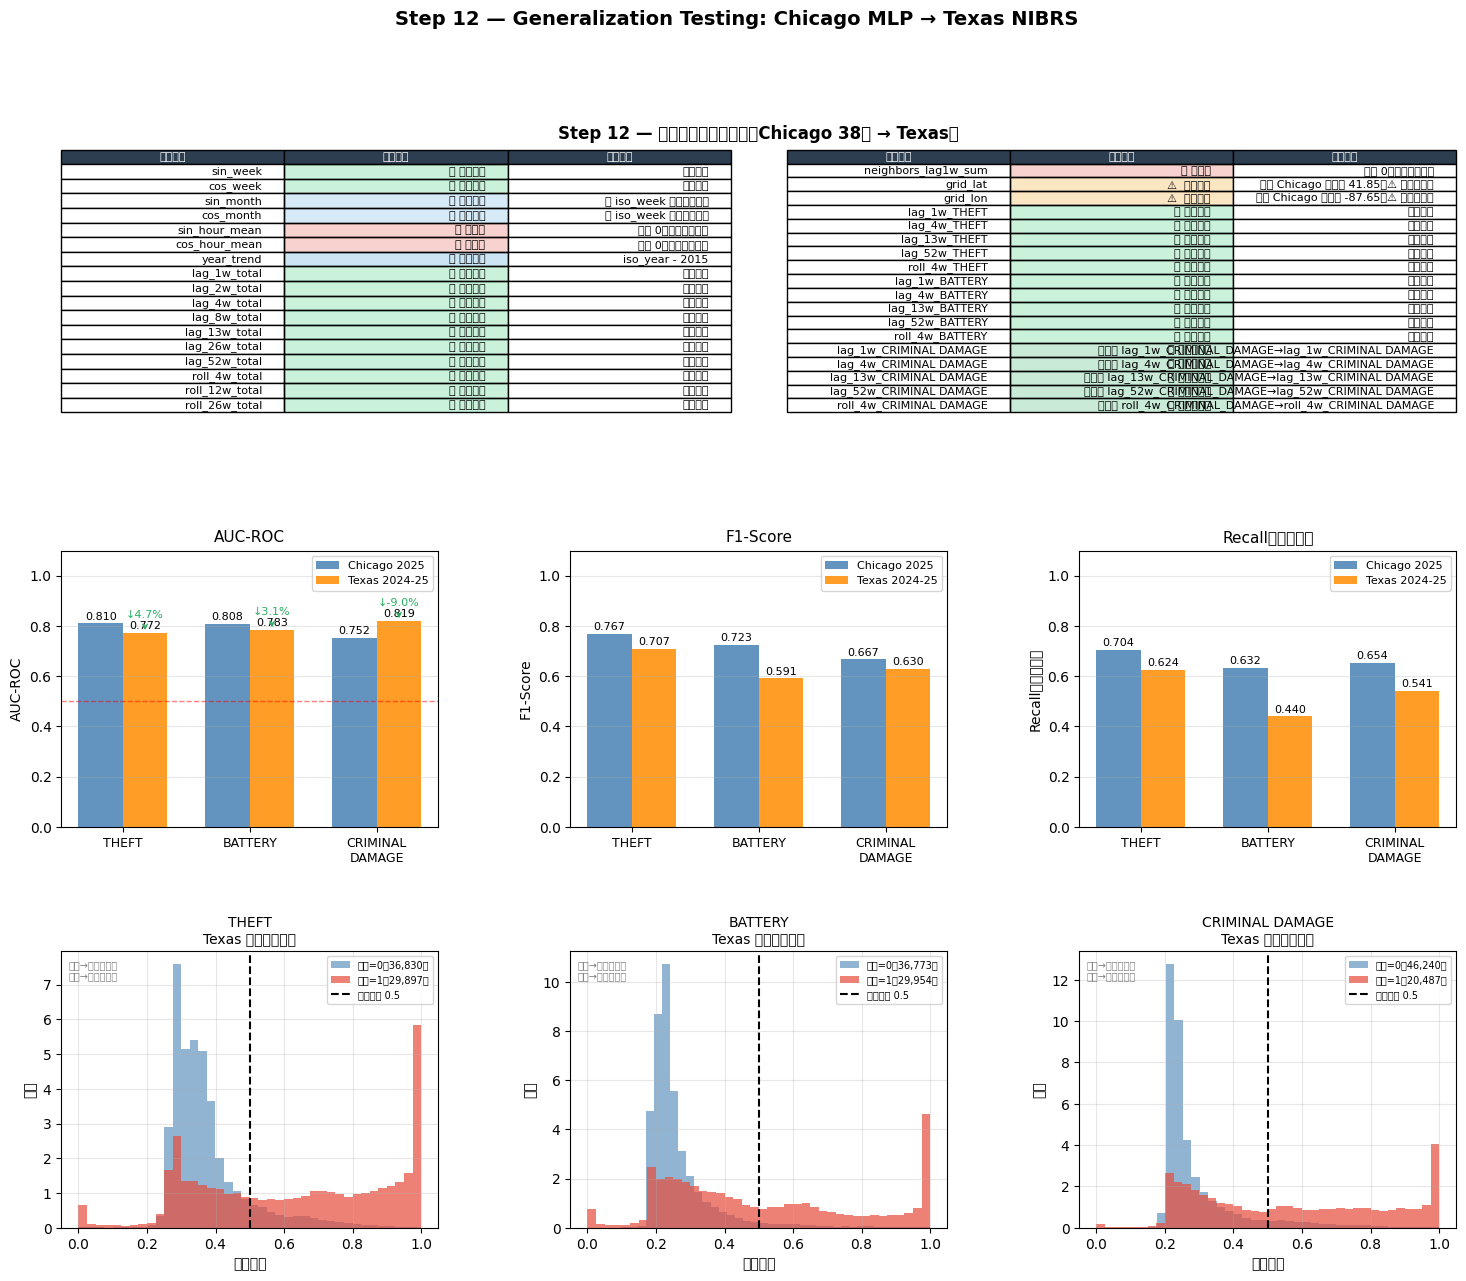

  图片已保存: d:\Trae_Projects\It5006\model_mlp_v2\outputs\12_generalization_report.png


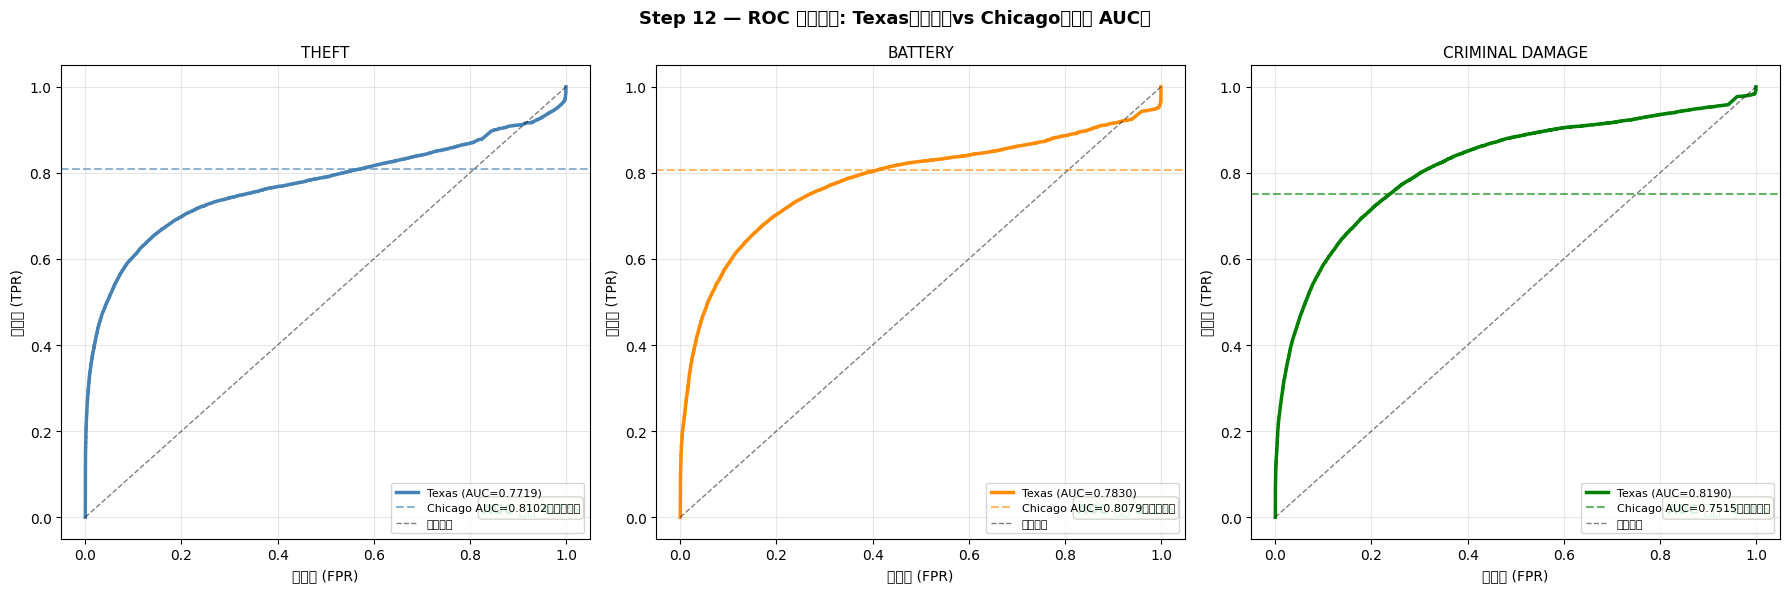

  图片已保存: d:\Trae_Projects\It5006\model_mlp_v2\outputs\12_texas_roc_curves.png

✓ Step 12 完成 — 泛化能力测试

  关键结论汇总:
  THEFT: Chicago AUC=0.8102 → Texas AUC=0.7719，下降 4.7%
  BATTERY: Chicago AUC=0.8079 → Texas AUC=0.7830，下降 3.1%
  CRIMINAL DAMAGE: Chicago AUC=0.7515 → Texas AUC=0.8190，下降 -9.0%

  完整报告见:
    outputs/12_feature_audit.txt        (特征对齐文字报告)
    outputs/12_generalization_report.png (综合可视化)
    outputs/12_texas_roc_curves.png      (ROC 曲线对比)


In [3]:
np.random.seed(RANDOM_SEED)


# ── Section 1: 数据加载与兼容性审计 ──────────────────────────────────────────

def load_texas_data(texas_csv: str) -> pd.DataFrame:
    """
    加载德克萨斯州 NIBRS 数据。

    使用 tx_external_shared_final_42cols.csv（54列版本），
    因为它同时包含特征（42列）和标签（label_THEFT/BATTERY/CRIMINAL_DAMAGE），
    以及用于分析的元数据（agency_id, iso_year, iso_week）。
    """
    print(f'  加载 Texas 数据: {texas_csv}')
    df = pd.read_csv(texas_csv)
    print(f'  形状: {df.shape}  (行={len(df):,}, 列={df.shape[1]})')
    print(f'  iso_year 分布: {df["iso_year"].value_counts().to_dict()}')
    print(f'  agency 数量: {df["agency_id"].nunique():,}')
    return df


def audit_feature_compatibility(feature_cols: list, df_tx: pd.DataFrame) -> dict:
    """
    审计 Texas 数据相对于 Chicago 38 维特征的兼容性。

    对每个 Chicago 特征：
      - 直接匹配：Texas 列名完全一致（或加下划线后一致）
      - 可推导：不存在但可由其他列计算
      - 需填充：无法获取，使用默认值

    返回字典供后续特征对齐使用。
    """
    # Texas 列名集合（用于快速查找）
    tx_cols = set(df_tx.columns)
    tx_cols_underscore = {c.replace(' ', '_') for c in tx_cols}  # 下划线版本

    audit = {}
    for feat in feature_cols:
        feat_esc = feat.replace(' ', '_')  # 处理 CRIMINAL DAMAGE → CRIMINAL_DAMAGE

        if feat in tx_cols:
            audit[feat] = {'status': 'direct',   'tx_col': feat,      'action': '直接使用'}
        elif feat_esc in tx_cols:
            audit[feat] = {'status': 'rename',   'tx_col': feat_esc,  'action': f'重命名 {feat_esc}→{feat}'}
        elif feat == 'year_trend':
            audit[feat] = {'status': 'derive',   'tx_col': None,      'action': 'iso_year - 2015'}
        elif feat in ('sin_month', 'cos_month'):
            audit[feat] = {'status': 'approx',   'tx_col': None,      'action': '从 iso_week 近似推导月份'}
        elif feat in ('sin_hour_mean', 'cos_hour_mean'):
            audit[feat] = {'status': 'impute_0', 'tx_col': None,      'action': '填充 0（无小时数据）'}
        elif feat == 'neighbors_lag1w_sum':
            audit[feat] = {'status': 'impute_0', 'tx_col': None,      'action': '填充 0（无空间网格）'}
        elif feat in ('grid_lat', 'grid_lon'):
            val = CHICAGO_BASE_LAT if feat == 'grid_lat' else CHICAGO_BASE_LON
            audit[feat] = {'status': 'impute_geo', 'tx_col': None,
                           'action': f'填充 Chicago 中心值 {val}（⚠️ 有局限性）'}
        else:
            audit[feat] = {'status': 'unknown', 'tx_col': None, 'action': '未知，填充 0'}

    return audit


def save_audit_report(audit: dict, feature_cols: list, out_path: str):
    """将兼容性审计结果保存为可读文字报告。"""
    status_counts = {}
    for info in audit.values():
        s = info['status']
        status_counts[s] = status_counts.get(s, 0) + 1

    lines = [
        '=' * 70,
        'Step 12 — 特征兼容性审计报告',
        f'Chicago 模型特征维度: {len(feature_cols)}',
        f'Texas 数据列数: 54（原始）',
        '=' * 70,
        '',
        f'✅ 直接可用 (direct/rename): {status_counts.get("direct",0) + status_counts.get("rename",0)} 维',
        f'🔧 近似推导 (approx/derive): {status_counts.get("approx",0) + status_counts.get("derive",0)} 维',
        f'⚠️  地理填充 (impute_geo):    {status_counts.get("impute_geo",0)} 维（精度有限）',
        f'❌ 零填充   (impute_0):       {status_counts.get("impute_0",0)} 维（信息缺失）',
        '',
        '逐特征明细:',
        '-' * 70,
    ]

    status_emoji = {
        'direct':     '✅',
        'rename':     '✅',
        'derive':     '🔧',
        'approx':     '🔧',
        'impute_0':   '❌',
        'impute_geo': '⚠️ ',
        'unknown':    '❓',
    }

    for feat in feature_cols:
        info = audit[feat]
        emoji = status_emoji.get(info['status'], '❓')
        lines.append(f'  {emoji}  {feat:<30}  {info["action"]}')

    lines += [
        '',
        '=' * 70,
        '重要局限性说明:',
        '  1. grid_lat/grid_lon 填充 Chicago 中心值（41.85, -87.65）。',
        '     Texas agencies 实际分布在 26°-36°N, 94°-106°W，',
        '     与 Chicago 训练值域完全不重叠，标准化后为极端异常值。',
        '     → 泛化 AUC 下降可能部分来源于此。',
        '  2. sin_hour_mean/cos_hour_mean = 0，即假设犯罪均匀分布在全天，',
        '     而 Chicago 模型实际学到了高峰时段规律（如深夜/傍晚）。',
        '  3. neighbors_lag1w_sum = 0，忽略了空间自相关效应。',
        '  4. Texas 时间范围（2024-2025）接近 Chicago 训练集末期，',
        '     时序特征（lag_52w_*）可能反映 2024 年之前的数据，',
        '     与 Chicago 同期分布可能更接近。',
        '=' * 70,
    ]

    with open(out_path, 'w', encoding='utf-8') as f:
        f.write('\n'.join(lines))
    print(f'  审计报告已保存: {out_path}')
    for line in lines:
        print('  ' + line)


# ── Section 2: 特征对齐 ──────────────────────────────────────────────────────

def align_texas_features(df_tx: pd.DataFrame, feature_cols: list,
                          audit: dict) -> np.ndarray:
    """
    将 Texas DataFrame 对齐到 Chicago 模型的 38 维特征空间。

    处理顺序（按 audit 状态）：
      1. direct    → 直接取列值
      2. rename    → 取下划线版本的列值
      3. derive    → year_trend = iso_year - 2015
      4. approx    → sin/cos_month 从 iso_week 近似
      5. impute_0  → 填 0
      6. impute_geo → 填 Chicago 中心坐标
    """
    n = len(df_tx)
    X = np.zeros((n, len(feature_cols)), dtype=np.float32)

    for j, feat in enumerate(feature_cols):
        info = audit[feat]
        status = info['status']

        if status == 'direct':
            X[:, j] = df_tx[feat].values

        elif status == 'rename':
            X[:, j] = df_tx[info['tx_col']].values

        elif status == 'derive':
            # year_trend = iso_year - 2015（基准年与 Chicago 模型一致）
            X[:, j] = (df_tx['iso_year'] - 2015).values

        elif status == 'approx':
            # 从 ISO 周近似推导月份（每月约 4.33 周）
            # 注意：这是粗略近似，误差约 ±2周
            approx_month = np.clip(np.ceil(df_tx['iso_week'].values / 4.3333), 1, 12)
            if feat == 'sin_month':
                X[:, j] = np.sin(2 * np.pi * approx_month / 12)
            elif feat == 'cos_month':
                X[:, j] = np.cos(2 * np.pi * approx_month / 12)

        elif status == 'impute_0':
            X[:, j] = 0.0   # 中性填充（信息缺失）

        elif status == 'impute_geo':
            if feat == 'grid_lat':
                X[:, j] = CHICAGO_BASE_LAT
            elif feat == 'grid_lon':
                X[:, j] = CHICAGO_BASE_LON

        else:
            X[:, j] = 0.0  # 未知情况

    print(f'  Texas 特征矩阵构建完成: {X.shape}')
    return X


# ── Section 3: 应用 Chicago Scaler + 预测 ───────────────────────────────────

def apply_scaler_and_predict(X_texas: np.ndarray, scaler,
                              mlp_models: dict, top3: list) -> tuple:
    """
    用 Chicago 训练的 StandardScaler 变换 Texas 特征，然后用 MLP 预测。

    重要：Scaler 已在 Chicago 2015-2024 数据上 fit，
    Texas 的数据分布可能与之不同，导致某些特征的标准化值超出正常范围。
    这是域迁移（domain shift）的体现，不需要修正，而是需要在结论中讨论。
    """
    # 应用 Chicago 的 StandardScaler（不重新 fit！）
    X_scaled = scaler.transform(X_texas)
    print(f'  已应用 Chicago StandardScaler（共 {X_scaled.shape[1]} 维）')

    # 检查标准化后的数值范围（超出 [-5, 5] 说明有较大域迁移）
    abs_max = np.abs(X_scaled).max(axis=0)
    extreme_feats = [(i, abs_max[i]) for i in range(len(abs_max)) if abs_max[i] > 5]
    if extreme_feats:
        print(f'  ⚠️  有 {len(extreme_feats)} 个特征标准化后超出 [-5,5] 范围（可能的域迁移）')

    # 用每个 MLP 模型预测
    probs = {}
    for crime in top3:
        if crime not in mlp_models:
            print(f'  跳过 {crime}（无 MLP 模型）')
            continue
        y_prob = mlp_models[crime](X_scaled)
        probs[crime] = y_prob
        pos_rate = (y_prob >= 0.5).mean() * 100
        print(f'  {crime}: 预测正样本率 = {pos_rate:.1f}%（阈值 0.5）')

    return X_scaled, probs


# ── Section 4: 指标计算 ──────────────────────────────────────────────────────

def compute_texas_metrics(probs: dict, df_tx: pd.DataFrame, top3: list) -> dict:
    """
    计算 Texas 数据上各犯罪类型的评估指标。

    标签列：label_THEFT, label_BATTERY, label_CRIMINAL_DAMAGE（Texas 用下划线）
    需要映射到 Chicago 的空格格式：CRIMINAL DAMAGE。
    """
    # Texas 标签列名映射
    label_map = {
        'THEFT':           'label_THEFT',
        'BATTERY':         'label_BATTERY',
        'CRIMINAL DAMAGE': 'label_CRIMINAL_DAMAGE',
    }

    texas_metrics = {}
    print('\n  Texas 测试集指标:')

    for crime in top3:
        if crime not in probs:
            continue

        label_col = label_map.get(crime)
        if label_col not in df_tx.columns:
            print(f'  警告: 找不到标签列 {label_col}，跳过 {crime}')
            continue

        y_true = df_tx[label_col].values
        y_prob = probs[crime]
        y_pred = (y_prob >= 0.5).astype(int)

        texas_metrics[crime] = {
            'precision': precision_score(y_true, y_pred, zero_division=0),
            'recall':    recall_score(y_true, y_pred, zero_division=0),
            'f1':        f1_score(y_true, y_pred, zero_division=0),
            'auc_roc':   roc_auc_score(y_true, y_prob),
            # 额外信息（用于分析）
            'n_samples':  len(y_true),
            'pos_rate':   y_true.mean(),
        }

        print(f'\n  [{crime}]')
        print(f'    Precision : {texas_metrics[crime]["precision"]:.4f}')
        print(f'    Recall    : {texas_metrics[crime]["recall"]:.4f}')
        print(f'    F1        : {texas_metrics[crime]["f1"]:.4f}')
        print(f'    AUC-ROC   : {texas_metrics[crime]["auc_roc"]:.4f}')
        print(f'    正样本率   : {texas_metrics[crime]["pos_rate"]*100:.1f}%')

    return texas_metrics


def interpret_generalization(chicago_metrics: dict, texas_metrics: dict, top3: list):
    """
    根据 AUC 下降幅度自动生成泛化能力解读。

    判断标准（基于域迁移文献的经验阈值）：
      AUC 下降 < 5%  → 泛化良好：时序自回归特征跨城市有效
      AUC 下降 5-15% → 中等泛化：部分特征（如空间/小时）存在域迁移
      AUC 下降 > 15% → 泛化差：模型对 Chicago 特定特征过拟合
    """
    print('\n  泛化能力解读:')
    print('  ' + '='*55)

    for crime in top3:
        if crime not in chicago_metrics or crime not in texas_metrics:
            continue

        chi_auc = chicago_metrics[crime]['auc_roc']
        tx_auc  = texas_metrics[crime]['auc_roc']
        drop    = chi_auc - tx_auc
        drop_pct = drop / chi_auc * 100

        if drop_pct < 5:
            verdict = '✅ 泛化良好'
            reason  = '时序滞后特征具有跨城市普适性'
        elif drop_pct < 15:
            verdict = '⚠️  中等泛化'
            reason  = '时序特征有效，但空间/小时特征域迁移导致部分性能损失'
        else:
            verdict = '❌ 泛化较差'
            reason  = '模型可能对 Chicago 特定地理特征过度依赖'

        print(f'\n  [{crime}]')
        print(f'    Chicago AUC: {chi_auc:.4f}  →  Texas AUC: {tx_auc:.4f}')
        print(f'    AUC 下降: {drop:.4f} ({drop_pct:.1f}%)')
        print(f'    结论: {verdict}')
        print(f'    分析: {reason}')


# ── Section 5: 可视化 ────────────────────────────────────────────────────────

def plot_generalization_report(audit: dict, feature_cols: list,
                                chicago_metrics: dict, texas_metrics: dict,
                                probs: dict, df_tx: pd.DataFrame,
                                top3: list, out_path: str):
    """
    综合对比可视化（3行布局）：
      行1: 特征对齐状态表（显示每维特征的处理方式）
      行2: Chicago vs Texas 的 AUC-ROC / F1 / Recall 分组柱状图
      行3: Texas 预测概率分布直方图（3种犯罪类型）

    运行后请检查：
      - 行2：Texas AUC 与 Chicago 的差距是否在可接受范围内（< 15%）
      - 行3：概率分布是否合理（双峰分布说明模型有区分能力）
    """
    fig = plt.figure(figsize=(18, 14))
    gs = plt.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

    # ── 行1：特征对齐状态汇总表 ──────────────────────────────────────────────
    ax_table = fig.add_subplot(gs[0, :])
    ax_table.axis('off')

    # 统计各状态数量
    status_order = ['direct', 'rename', 'derive', 'approx', 'impute_0', 'impute_geo']
    status_labels = {
        'direct':     ('✅ 直接使用',    '#2ECC71'),
        'rename':     ('✅ 重命名使用',   '#27AE60'),
        'derive':     ('🔧 公式推导',    '#3498DB'),
        'approx':     ('🔧 近似推导',    '#5DADE2'),
        'impute_0':   ('❌ 零填充',      '#E74C3C'),
        'impute_geo': ('⚠️  坐标近似',   '#F39C12'),
    }

    table_data = []
    cell_colors = []
    for feat in feature_cols:
        info = audit[feat]
        st = info['status']
        label, color = status_labels.get(st, ('❓ 未知', '#95A5A6'))
        table_data.append([feat, label, info['action']])
        cell_colors.append(['white', color + '40', 'white'])

    # 分两栏显示（19个特征一行太多）
    mid = len(feature_cols) // 2
    col_width = [0.18, 0.12, 0.2]
    tbl = ax_table.table(
        cellText=table_data[:mid],
        colLabels=['特征名称', '处理状态', '处理方式'],
        cellColours=cell_colors[:mid],
        loc='upper left',
        bbox=[0, 0.05, 0.48, 0.95]
    )
    tbl2 = ax_table.table(
        cellText=table_data[mid:],
        colLabels=['特征名称', '处理状态', '处理方式'],
        cellColours=cell_colors[mid:],
        loc='upper right',
        bbox=[0.52, 0.05, 0.48, 0.95]
    )
    for t in [tbl, tbl2]:
        t.auto_set_font_size(False)
        t.set_fontsize(8)
        t.scale(1, 1.4)
        for (row, col), cell in t.get_celld().items():
            if row == 0:
                cell.set_facecolor('#2C3E50')
                cell.set_text_props(color='white', fontweight='bold')
    ax_table.set_title('Step 12 — 特征兼容性对齐状态（Chicago 38维 → Texas）',
                       fontsize=12, fontweight='bold', pad=8)

    # ── 行2：AUC / F1 / Recall 对比柱状图 ────────────────────────────────────
    metrics_to_compare = [
        ('auc_roc', 'AUC-ROC'),
        ('f1',      'F1-Score'),
        ('recall',  'Recall（召回率）'),
    ]
    x = np.arange(len(top3))
    width = 0.35

    for col_idx, (metric_key, metric_name) in enumerate(metrics_to_compare):
        ax = fig.add_subplot(gs[1, col_idx])

        chi_vals = [chicago_metrics.get(c, {}).get(metric_key, 0) for c in top3]
        tx_vals  = [texas_metrics.get(c,  {}).get(metric_key, 0) for c in top3]

        bars_chi = ax.bar(x - width/2, chi_vals, width,
                          label='Chicago 2025', color='steelblue', alpha=0.85)
        bars_tx  = ax.bar(x + width/2, tx_vals,  width,
                          label='Texas 2024-25', color='darkorange', alpha=0.85)

        # 标注数值
        for bar, v in zip(list(bars_chi) + list(bars_tx),
                          chi_vals + tx_vals):
            if v > 0:
                ax.text(bar.get_x() + bar.get_width()/2,
                        bar.get_height() + 0.008,
                        f'{v:.3f}', ha='center', va='bottom', fontsize=8)

        # 标注 AUC 下降箭头
        if metric_key == 'auc_roc':
            for i, (cv, tv) in enumerate(zip(chi_vals, tx_vals)):
                if cv > 0:
                    drop_pct = (cv - tv) / cv * 100
                    color = '#27AE60' if drop_pct < 5 else ('#E67E22' if drop_pct < 15 else '#E74C3C')
                    ax.annotate(f'↓{drop_pct:.1f}%',
                                xy=(x[i] + width/2, tv),
                                xytext=(x[i] + width/2, tv + 0.06),
                                ha='center', fontsize=8, color=color,
                                arrowprops=dict(arrowstyle='->', color=color, lw=1))

        ax.set_xticks(x)
        ax.set_xticklabels([c.replace(' ', '\n') for c in top3], fontsize=9)
        ax.set_ylim(0, 1.1)
        ax.set_ylabel(metric_name)
        ax.set_title(metric_name, fontsize=11)
        ax.legend(fontsize=8)
        ax.grid(axis='y', alpha=0.3)
        if metric_key == 'auc_roc':
            ax.axhline(0.5, color='red', linestyle='--', linewidth=1, alpha=0.5,
                       label='随机基线')

    # ── 行3：Texas 预测概率分布直方图 ─────────────────────────────────────────
    colors_crime = ['steelblue', 'darkorange', 'green']
    label_map = {
        'THEFT':           'label_THEFT',
        'BATTERY':         'label_BATTERY',
        'CRIMINAL DAMAGE': 'label_CRIMINAL_DAMAGE',
    }

    for col_idx, (crime, color) in enumerate(zip(top3, colors_crime)):
        ax = fig.add_subplot(gs[2, col_idx])

        if crime not in probs:
            ax.text(0.5, 0.5, '无预测结果', transform=ax.transAxes,
                    ha='center', va='center')
            continue

        y_prob = probs[crime]
        y_true = df_tx[label_map.get(crime, '')].values if label_map.get(crime, '') in df_tx.columns else None

        # 按真实标签分别绘制概率分布
        if y_true is not None:
            pos_probs = y_prob[y_true == 1]
            neg_probs = y_prob[y_true == 0]
            ax.hist(neg_probs, bins=40, alpha=0.6, color='steelblue',
                    label=f'实际=0（{len(neg_probs):,}）', density=True)
            ax.hist(pos_probs, bins=40, alpha=0.7, color='#e74c3c',
                    label=f'实际=1（{len(pos_probs):,}）', density=True)
        else:
            ax.hist(y_prob, bins=50, color=color, alpha=0.8, density=True)

        ax.axvline(0.5, color='black', linestyle='--', linewidth=1.5, label='决策阈值 0.5')
        ax.set_xlabel('预测概率')
        ax.set_ylabel('密度')
        ax.set_title(f'{crime}\nTexas 预测概率分布', fontsize=10)
        ax.legend(fontsize=7)
        ax.grid(alpha=0.3)

        # 注释：好的模型应产生双峰分布（0附近和1附近各一峰）
        ax.text(0.02, 0.97,
                '双峰→有区分能力\n单峰→区分能力差',
                transform=ax.transAxes, va='top', fontsize=7,
                color='gray', style='italic')

    fig.suptitle('Step 12 — Generalization Testing: Chicago MLP → Texas NIBRS',
                 fontsize=14, fontweight='bold')
    plt.savefig(out_path, dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f'  图片已保存: {out_path}')


def plot_roc_comparison(probs: dict, df_tx: pd.DataFrame,
                         chicago_metrics: dict, top3: list, out_path: str):
    """
    在同一张图上绘制 Texas 和 Chicago 的 ROC 曲线以对比泛化能力。

    Chicago 使用已保存的 AUC 值（无法重新获取 ROC 数据点，仅标注 AUC）。
    Texas 使用实际计算的 ROC 曲线。

    运行后请检查：
      - Texas ROC 曲线是否仍在随机基线（y=x）以上（AUC > 0.5）
      - 曲线形状是否合理（不应出现大量非单调波动）
    """
    label_map = {
        'THEFT':           'label_THEFT',
        'BATTERY':         'label_BATTERY',
        'CRIMINAL DAMAGE': 'label_CRIMINAL_DAMAGE',
    }
    colors = ['steelblue', 'darkorange', 'green']

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle('Step 12 — ROC 曲线对比: Texas（实测）vs Chicago（参考 AUC）',
                 fontsize=13, fontweight='bold')

    for ax, crime, color in zip(axes, top3, colors):
        if crime not in probs:
            ax.text(0.5, 0.5, '无预测', transform=ax.transAxes,
                    ha='center', va='center')
            continue

        label_col = label_map.get(crime, '')
        if label_col not in df_tx.columns:
            continue

        y_true = df_tx[label_col].values
        y_prob = probs[crime]
        fpr, tpr, _ = roc_curve(y_true, y_prob)
        tx_auc = roc_auc_score(y_true, y_prob)

        # Texas ROC（实线）
        ax.plot(fpr, tpr, color=color, linewidth=2.5,
                label=f'Texas (AUC={tx_auc:.4f})')

        # Chicago 参考（用虚线标注 AUC 水平，无实际曲线数据）
        chi_auc = chicago_metrics.get(crime, {}).get('auc_roc', None)
        if chi_auc:
            ax.axhline(chi_auc, color=color, linestyle='--', linewidth=1.5, alpha=0.6,
                       label=f'Chicago AUC={chi_auc:.4f}（参考线）')

        ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='随机基线')
        ax.set_xlabel('假正率 (FPR)')
        ax.set_ylabel('真正率 (TPR)')
        ax.set_title(crime, fontsize=11)
        ax.legend(fontsize=8, loc='lower right')
        ax.grid(alpha=0.3)

        # 标注性能差距
        if chi_auc:
            drop_pct = (chi_auc - tx_auc) / chi_auc * 100
            verdict_color = '#27AE60' if drop_pct < 5 else ('#E67E22' if drop_pct < 15 else '#E74C3C')
            ax.text(0.98, 0.05,
                    f'AUC 下降 {drop_pct:.1f}%',
                    transform=ax.transAxes, ha='right', va='bottom',
                    color=verdict_color, fontsize=10, fontweight='bold',
                    bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

    plt.tight_layout()
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'  图片已保存: {out_path}')


# ── 主流程 ────────────────────────────────────────────────────────────────────

def main():
    os.makedirs(OUTPUT_DIR, exist_ok=True)

    print('=' * 60)
    print('Step 12 — 泛化能力测试（Chicago MLP → Texas NIBRS）')
    print('=' * 60)

    # 1. 加载 Texas 数据
    print('\n[1/6] 加载 Texas NIBRS 数据...')
    df_tx = load_texas_data(TEXAS_CSV)

    # 2. 加载 Chicago 模型资产
    print('\n[2/6] 加载 Chicago 模型资产...')
    with open(os.path.join(OUTPUT_DIR, '03_feature_cols.pkl'), 'rb') as f:
        feature_cols = pickle.load(f)
    with open(os.path.join(OUTPUT_DIR, '04_scaler.pkl'), 'rb') as f:
        scaler = pickle.load(f)
    with open(os.path.join(OUTPUT_DIR, '01_top3.pkl'), 'rb') as f:
        top3 = pickle.load(f)

    # 加载 Chicago MLP 模型
    mlp_dir = os.path.join(OUTPUT_DIR, '06_mlp_final_models')
    mlp_models = {}
    for crime in top3:
        crime_dir = os.path.join(mlp_dir, crime.replace(' ', '_') + '.keras')
        if os.path.exists(crime_dir):
            m = tf.keras.models.load_model(crime_dir)
            mlp_models[crime] = (lambda mo: lambda X: mo.predict(X, verbose=0).ravel())(m)
            print(f'  已加载 {crime} 模型')
        else:
            print(f'  ⚠️  找不到 {crime_dir}，请先运行 step06')

    if not mlp_models:
        print('  错误: 无法加载任何 MLP 模型，请先运行 step06')
        return

    # 加载 Chicago 测试集指标（对比基准）
    chicago_metrics = {}
    chi_metrics_path = os.path.join(OUTPUT_DIR, '06_mlp_metrics.pkl')
    if os.path.exists(chi_metrics_path):
        with open(chi_metrics_path, 'rb') as f:
            chicago_metrics = pickle.load(f)
        print(f'  已加载 Chicago 对比基准（2025 测试集）')
    else:
        print('  ⚠️  06_mlp_metrics.pkl 不存在，将跳过 Chicago 对比')

    # 3. 特征兼容性审计
    print('\n[3/6] 特征兼容性审计...')
    audit = audit_feature_compatibility(feature_cols, df_tx)
    save_audit_report(
        audit, feature_cols,
        out_path=os.path.join(OUTPUT_DIR, '12_feature_audit.txt')
    )

    # 4. 特征对齐 + Scaler + 预测
    print('\n[4/6] 特征对齐与预测...')
    X_texas = align_texas_features(df_tx, feature_cols, audit)
    X_scaled, probs = apply_scaler_and_predict(X_texas, scaler, mlp_models, top3)

    # 5. 计算指标 + 泛化解读
    print('\n[5/6] 计算 Texas 测试集指标...')
    texas_metrics = compute_texas_metrics(probs, df_tx, top3)
    interpret_generalization(chicago_metrics, texas_metrics, top3)

    # 保存指标
    with open(os.path.join(OUTPUT_DIR, '12_generalization_metrics.pkl'), 'wb') as f:
        pickle.dump(texas_metrics, f)
    print('\n  已保存: 12_generalization_metrics.pkl')

    # 6. 可视化
    print('\n[6/6] 生成可视化...')
    plot_generalization_report(
        audit, feature_cols, chicago_metrics, texas_metrics,
        probs, df_tx, top3,
        out_path=os.path.join(OUTPUT_DIR, '12_generalization_report.png')
    )
    plot_roc_comparison(
        probs, df_tx, chicago_metrics, top3,
        out_path=os.path.join(OUTPUT_DIR, '12_texas_roc_curves.png')
    )

    print('\n✓ Step 12 完成 — 泛化能力测试')
    print('\n  关键结论汇总:')
    for crime in top3:
        if crime in chicago_metrics and crime in texas_metrics:
            chi_auc = chicago_metrics[crime]['auc_roc']
            tx_auc  = texas_metrics[crime]['auc_roc']
            drop    = (chi_auc - tx_auc) / chi_auc * 100
            print(f'  {crime}: Chicago AUC={chi_auc:.4f} → Texas AUC={tx_auc:.4f}，'
                  f'下降 {drop:.1f}%')
    print('\n  完整报告见:')
    print('    outputs/12_feature_audit.txt        (特征对齐文字报告)')
    print('    outputs/12_generalization_report.png (综合可视化)')
    print('    outputs/12_texas_roc_curves.png      (ROC 曲线对比)')


main()

### Texas NIBRS — Precision / Recall / F1 对比 / Full Metrics Comparison

In [1]:
# -- 常量兜底 --
import os as _os
if 'OUTPUT_DIR' not in dir():
    NOTEBOOK_DIR = _os.getcwd()
    OUTPUT_DIR = _os.path.join(NOTEBOOK_DIR, 'outputs')
    TOP3 = ['THEFT', 'BATTERY', 'CRIMINAL DAMAGE']

import pickle, os, pandas as pd

chi = pickle.load(open(os.path.join(OUTPUT_DIR, '06_mlp_metrics.pkl'), 'rb'))
tex = pickle.load(open(os.path.join(OUTPUT_DIR, '12_generalization_metrics.pkl'), 'rb'))

rows = []
for crime in TOP3:
    rows.append({'Crime': crime, 'Dataset': 'Chicago 2025 (Test)',
                 'Precision': round(chi[crime]['precision'], 4),
                 'Recall':    round(chi[crime]['recall'],    4),
                 'F1-Score':  round(chi[crime]['f1'],        4),
                 'AUC-ROC':   round(chi[crime]['auc_roc'],   4)})
    auc_drop = (tex[crime]['auc_roc'] - chi[crime]['auc_roc']) / chi[crime]['auc_roc'] * 100
    rows.append({'Crime': crime, 'Dataset': 'Texas NIBRS (Zero-shot)',
                 'Precision': round(tex[crime]['precision'], 4),
                 'Recall':    round(tex[crime]['recall'],    4),
                 'F1-Score':  round(tex[crime]['f1'],        4),
                 'AUC-ROC':   round(tex[crime]['auc_roc'],   4)})

df = pd.DataFrame(rows).set_index(['Crime', 'Dataset'])
print('=== MLP: Chicago vs Texas — Full Metrics Comparison ===')
print(df.to_string())

print()
print('=== AUC Change (Texas vs Chicago) ===')
for crime in TOP3:
    chi_auc = chi[crime]['auc_roc']
    tex_auc = tex[crime]['auc_roc']
    drop = (tex_auc - chi_auc) / chi_auc * 100
    print(f'  {crime}: {chi_auc:.4f} -> {tex_auc:.4f}  ({drop:+.1f}%)')


=== MLP: Chicago vs Texas — Full Metrics Comparison ===
                                         Precision  Recall  F1-Score  AUC-ROC
Crime           Dataset                                                      
THEFT           Chicago 2025 (Test)         0.8439  0.7038    0.7675   0.8102
                Texas NIBRS (Zero-shot)     0.8167  0.6236    0.7072   0.7719
BATTERY         Chicago 2025 (Test)         0.8453  0.6320    0.7232   0.8079
                Texas NIBRS (Zero-shot)     0.9011  0.4402    0.5915   0.7830
CRIMINAL DAMAGE Chicago 2025 (Test)         0.6794  0.6543    0.6666   0.7515
                Texas NIBRS (Zero-shot)     0.7549  0.5409    0.6302   0.8190

=== AUC Change (Texas vs Chicago) ===
  THEFT: 0.8102 -> 0.7719  (-4.7%)
  BATTERY: 0.8079 -> 0.7830  (-3.1%)
  CRIMINAL DAMAGE: 0.7515 -> 0.8190  (+9.0%)


## Step 13 — 时空精度评估（Spatial & Temporal Accuracy Evaluation）

针对队友提出的"缺乏系统性时空评估"问题，本步骤在**不修改任何已有步骤**的前提下，
复用 pkl 中间文件，新增以下两类评估：

**Spatial Accuracy Evaluation（空间精度评估）**
- A. 逐网格 AUC 分布直方图（662个活跃网格）
- B. 热点命中率曲线 Hotspot Hit Rate @ Top-K%（K=5~30%）
- C. 高风险 vs 低风险网格 AUC 对比（按犯罪密度中位数分组）

**Temporal Accuracy Measures（时间精度评估）**
- A. 按月份（1-12月）的 AUC/F1 折线图
- B. 按季度（Q1-Q4）和季节（春夏秋冬）的分组指标

**输出**: `13_spatial_accuracy.png`, `13_temporal_accuracy.png`, `13_spatiotemporal_results.pkl`

测试集: 29577 行 | 661 网格 | 52 周

=== 运行评估 ===

-- THEFT --
  有效网格 (n>=10): 639, 平均 AUC: 0.5959
 risk_group       f1  roc_auc
   Low Risk 0.037456 0.609637
Medium Risk 0.518307 0.595247
  High Risk 0.930522 0.579729
quarter       f1  roc_auc
     Q1 0.751419 0.807683
     Q2 0.779475 0.810996
     Q3 0.784429 0.812443
     Q4 0.752006 0.809527

-- BATTERY --
  有效网格 (n>=10): 639, 平均 AUC: 0.5860
 risk_group       f1  roc_auc
   Low Risk 0.006045 0.603038
Medium Risk 0.344817 0.588075
  High Risk 0.910813 0.565383
quarter       f1  roc_auc
     Q1 0.694614 0.791255
     Q2 0.755305 0.817601
     Q3 0.740320 0.815808
     Q4 0.696469 0.806715

-- CRIMINAL DAMAGE --
  有效网格 (n>=10): 639, 平均 AUC: 0.5916
 risk_group       f1  roc_auc
   Low Risk 0.009935 0.621065
Medium Risk 0.360219 0.590496
  High Risk 0.804517 0.564456
quarter       f1  roc_auc
     Q1 0.633588 0.739840
     Q2 0.689112 0.755918
     Q3 0.689802 0.763115
     Q4 0.648126 0.743953


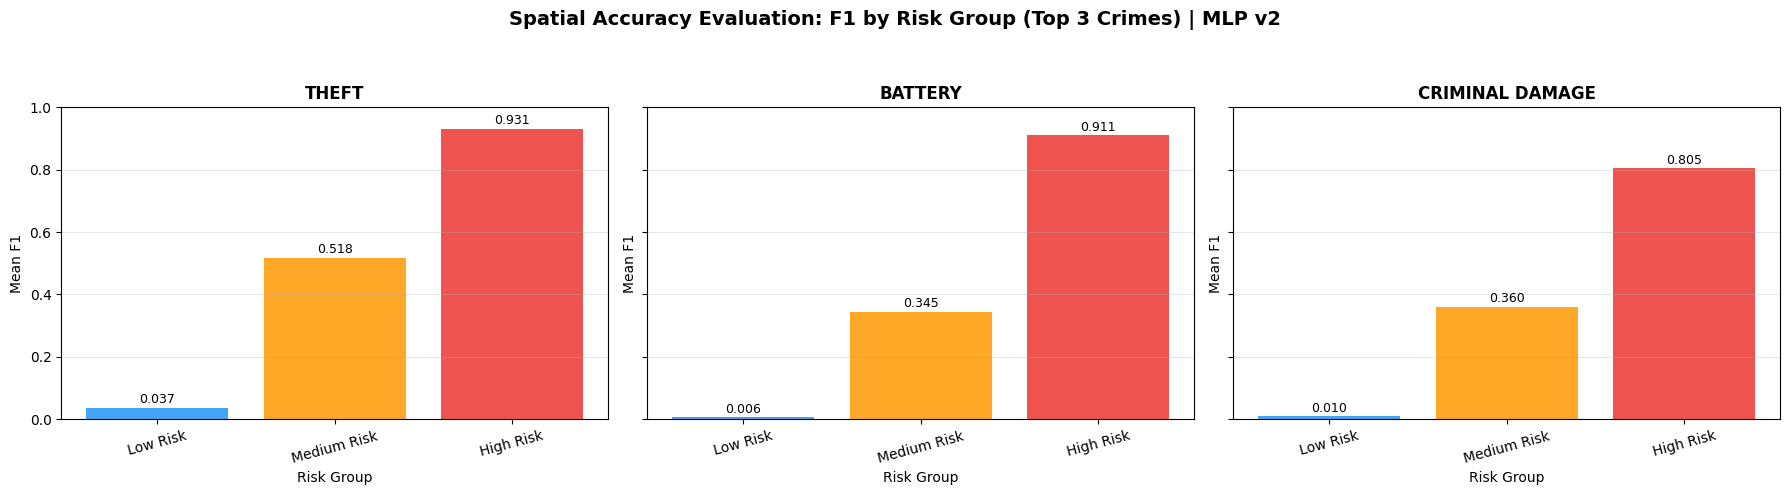

已保存: 13_spatial_risk_groups.png


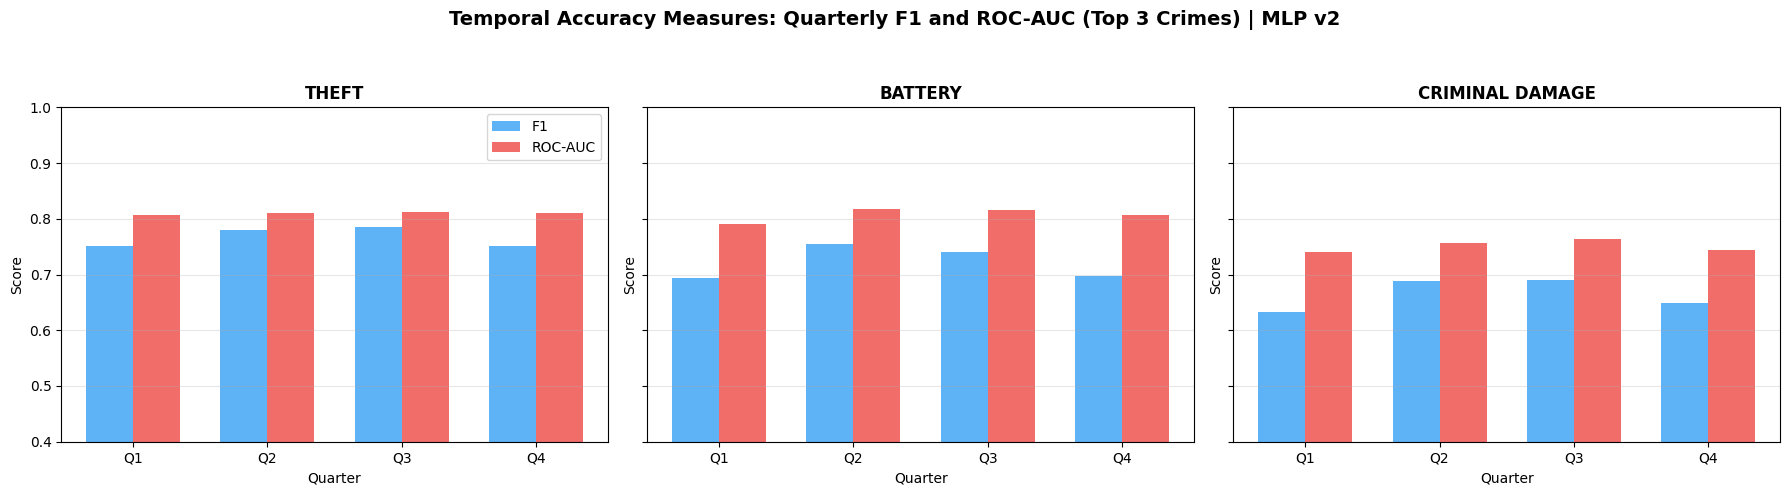

已保存: 13_temporal_quarterly.png


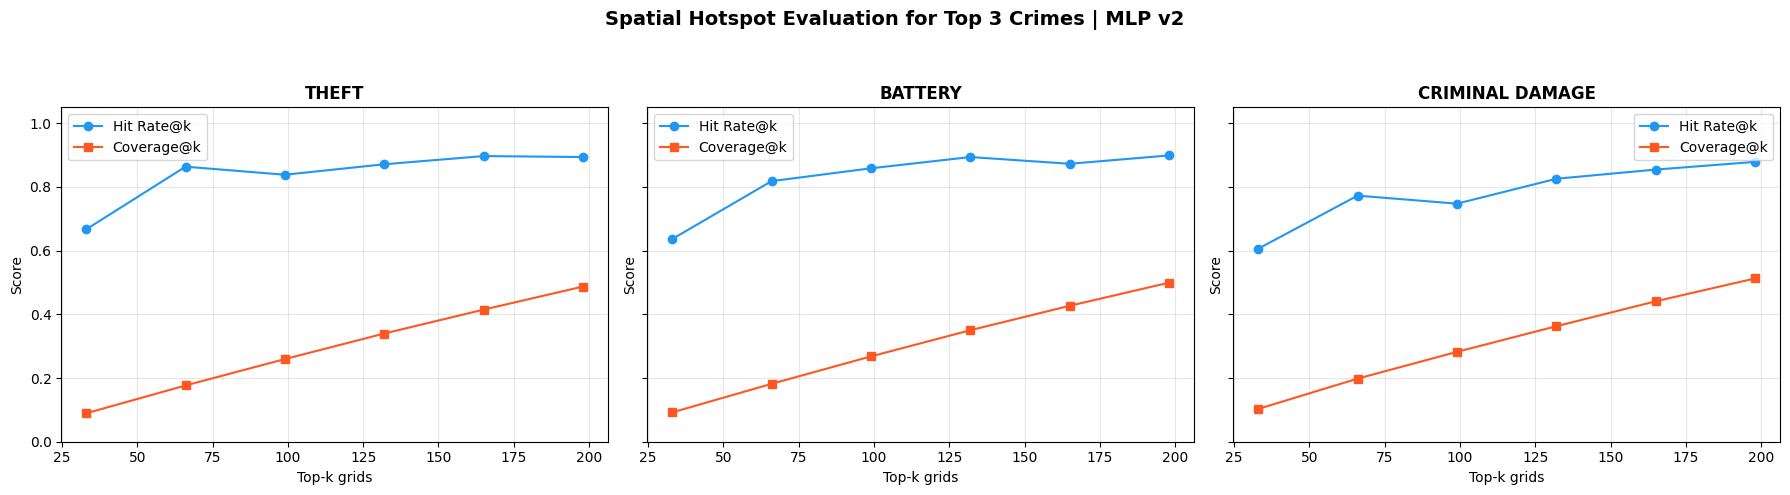

已保存: 13_spatial_hotspot.png


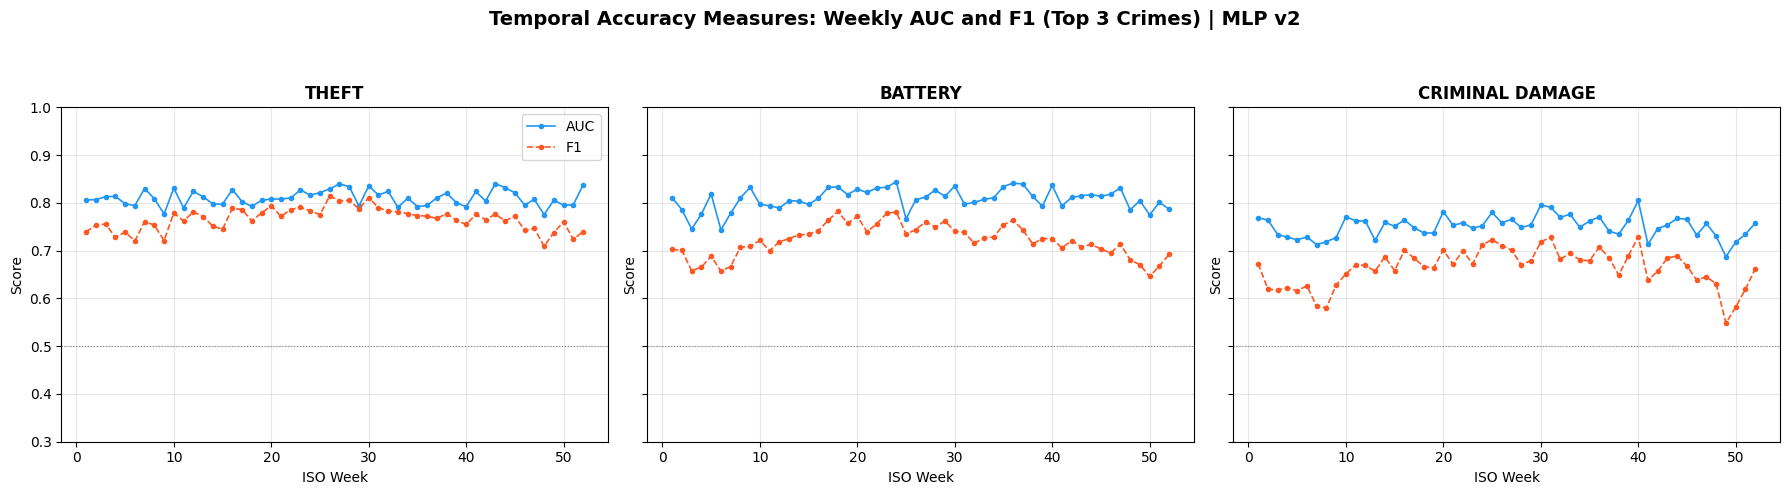

已保存: 13_temporal_weekly.png

✓ Step 13 完成
  13_spatial_risk_groups.png  -- 低/中/高风险网格 F1 对比 (1x3)
  13_spatial_hotspot.png      -- 热点命中率 & 覆盖率曲线 (1x3)
  13_temporal_quarterly.png   -- 季度 F1 & AUC (1x3)
  13_temporal_weekly.png      -- 周度 AUC & F1 折线 (1x3)
  13_spatiotemporal_results.pkl


In [10]:
# -- 常量兜底（如未运行 Cell 1 则自动补充定义）
import os as _os
if 'OUTPUT_DIR' not in dir():
    NOTEBOOK_DIR = _os.getcwd()
    OUTPUT_DIR   = _os.path.join(NOTEBOOK_DIR, 'outputs')
    TEST_YEAR    = 2025
    TOP3         = ['THEFT', 'BATTERY', 'CRIMINAL DAMAGE']

# -- Step 13: 时空精度评估（对齐 XGBoost 评估框架）
import pickle, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (accuracy_score, precision_score,
                              recall_score, f1_score, roc_auc_score)
import tensorflow as tf

# 1. 加载数据
agg          = pickle.load(open(os.path.join(OUTPUT_DIR, '03_agg_features.pkl'), 'rb'))
X_test       = pickle.load(open(os.path.join(OUTPUT_DIR, '04_X_test.pkl'), 'rb'))
feature_cols = pickle.load(open(os.path.join(OUTPUT_DIR, '03_feature_cols.pkl'), 'rb'))
top3         = pickle.load(open(os.path.join(OUTPUT_DIR, '01_top3.pkl'), 'rb'))

mlp_dir = os.path.join(OUTPUT_DIR, '06_mlp_final_models')
models  = {c: tf.keras.models.load_model(
               os.path.join(mlp_dir, c.replace(' ', '_') + '.keras'))
           for c in top3}

# 与 Step 04 保持一致：先 dropna(subset=feature_cols) 再按年份分割
agg_clean = agg.dropna(subset=feature_cols).copy()
train_df  = agg_clean[agg_clean['iso_year'] != TEST_YEAR].copy()
test_df   = agg_clean[agg_clean['iso_year'] == TEST_YEAR].copy().reset_index(drop=True)

for crime in top3:
    proba = models[crime].predict(X_test, verbose=0).flatten()
    test_df['_prob_' + crime] = proba
    test_df['_pred_' + crime] = (proba > 0.5).astype(int)

print('测试集: {} 行 | {} 网格 | {} 周'.format(
    len(test_df), test_df['grid_id'].nunique(), test_df['iso_week'].nunique()))

# 2. 通用分组评估函数（与 XGBoost 一致）
def safe_group_metrics(df):
    y_true = df['y_true'].values
    y_pred = df['y_pred'].values
    y_prob = df['y_prob'].values
    return pd.Series({
        'n_samples':     len(df),
        'positive_rate': float(y_true.mean()),
        'accuracy':      float(accuracy_score(y_true, y_pred)),
        'precision':     float(precision_score(y_true, y_pred, zero_division=0)),
        'recall':        float(recall_score(y_true, y_pred, zero_division=0)),
        'f1':            float(f1_score(y_true, y_pred, zero_division=0)),
        'roc_auc':       float(roc_auc_score(y_true, y_prob))
                         if len(np.unique(y_true)) == 2 else float('nan'),
    })

def build_eval_df(crime):
    df = test_df[['grid_id', 'iso_week']].copy()
    df['y_true'] = test_df['label_' + crime].values
    df['y_pred'] = test_df['_pred_' + crime].values
    df['y_prob'] = test_df['_prob_' + crime].values
    return df

# 3. 空间评估（3风险组，历史训练数据，与 XGBoost 一致）
def run_spatial_evaluation(crime):
    eval_df = build_eval_df(crime)
    spatial_eval_df = (
        eval_df.groupby('grid_id')
        .apply(safe_group_metrics, include_groups=False)
        .reset_index()
    )
    spatial_filtered = spatial_eval_df[spatial_eval_df['n_samples'] >= 10].copy()
    train_risk = (
        train_df.groupby('grid_id')['label_' + crime]
        .mean().reset_index()
        .rename(columns={'label_' + crime: 'historical_risk'})
    )
    sw = spatial_filtered.merge(train_risk, on='grid_id', how='left')
    sw['risk_group'] = pd.qcut(
        sw['historical_risk'].rank(method='first'),
        q=3, labels=['Low Risk', 'Medium Risk', 'High Risk']
    )
    risk_group_summary = (
        sw.groupby('risk_group', observed=True)
        [['accuracy','precision','recall','f1','roc_auc']]
        .mean().reset_index()
    )
    return spatial_eval_df, spatial_filtered, risk_group_summary

# 4. 热点评估（绝对 k，输出 hit_rate + coverage，与 XGBoost 一致）
def compute_hotspot_metrics(crime, k_list=None):
    eval_df = build_eval_df(crime)
    n_grids = eval_df['grid_id'].nunique()
    if k_list is None:
        k_list = sorted({max(1, int(n_grids * p))
                         for p in [0.05, 0.10, 0.15, 0.20, 0.25, 0.30]})
    grid_summary = (
        eval_df.groupby('grid_id')
        .agg(true_count=('y_true', 'sum'),
             pred_count=('y_pred', 'sum'),
             pred_score=('y_prob', 'sum'),
             n_samples=('y_true', 'size'))
        .reset_index()
    )
    total_true = grid_summary['true_count'].sum()
    results = []
    for k in k_list:
        true_topk    = set(grid_summary.nlargest(k, 'true_count')['grid_id'])
        pred_topk_df = grid_summary.nlargest(k, 'pred_score')
        pred_topk    = set(pred_topk_df['grid_id'])
        hit_count    = len(true_topk & pred_topk)
        coverage     = float(pred_topk_df['true_count'].sum()) / total_true                        if total_true > 0 else float('nan')
        results.append({'k': k, 'hit_rate': hit_count / k, 'coverage': coverage})
    return grid_summary, pd.DataFrame(results)

# 5. 时间评估（iso_week 周 + pd.cut 季度，与 XGBoost 一致）
def run_temporal_evaluation(crime):
    eval_df = build_eval_df(crime)
    weekly_df = (
        eval_df.groupby('iso_week')
        .apply(safe_group_metrics, include_groups=False)
        .reset_index()
    )
    tmp = eval_df.copy()
    tmp['quarter'] = pd.cut(tmp['iso_week'], bins=[0, 13, 26, 39, 53],
                            labels=['Q1', 'Q2', 'Q3', 'Q4'])
    quarter_df = (
        tmp.groupby('quarter', observed=True)
        .apply(safe_group_metrics, include_groups=False)
        .reset_index()
    )
    return weekly_df, quarter_df

# 6. 运行所有评估
spatial_outputs  = {}
hotspot_outputs  = {}
temporal_outputs = {}

print('\n=== 运行评估 ===')
for crime in top3:
    print('\n-- {} --'.format(crime))
    s_eval, s_filt, risk_summary = run_spatial_evaluation(crime)
    spatial_outputs[crime] = {
        'spatial_eval_df':    s_eval,
        'spatial_filtered':   s_filt,
        'risk_group_summary': risk_summary,
    }
    print('  有效网格 (n>=10): {}, 平均 AUC: {:.4f}'.format(
        len(s_filt), s_filt['roc_auc'].mean()))
    print(risk_summary[['risk_group', 'f1', 'roc_auc']].to_string(index=False))

    g_sum, h_df = compute_hotspot_metrics(crime)
    hotspot_outputs[crime] = {'grid_summary': g_sum, 'hotspot_metrics_df': h_df}

    w_df, q_df = run_temporal_evaluation(crime)
    temporal_outputs[crime] = {'weekly_df': w_df, 'quarter_df': q_df}
    print(q_df[['quarter', 'f1', 'roc_auc']].to_string(index=False))

# 7. 可视化（1x3 subplots，与 XGBoost 同风格）

# 图1：空间 F1 by 风险组（对应 XGBoost cell 64）
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
for ax, crime in zip(axes, top3):
    df_plot = spatial_outputs[crime]['risk_group_summary']
    bars = ax.bar(df_plot['risk_group'], df_plot['f1'],
                  color=['#42A5F5', '#FFA726', '#EF5350'])
    for bar in bars:
        h = bar.get_height()
        if h == h:  # not nan
            ax.text(bar.get_x() + bar.get_width() / 2, h + 0.005,
                    '{:.3f}'.format(h), ha='center', va='bottom', fontsize=9)
    ax.set_title(crime, fontsize=12, fontweight='bold')
    ax.set_xlabel('Risk Group')
    ax.set_ylabel('Mean F1')
    ax.tick_params(axis='x', labelrotation=15)
    ax.set_ylim(0, 1)
    ax.grid(axis='y', alpha=0.3)
plt.suptitle('Spatial Accuracy Evaluation: F1 by Risk Group (Top 3 Crimes) | MLP v2',
             fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig(os.path.join(OUTPUT_DIR, '13_spatial_risk_groups.png'), dpi=150, bbox_inches='tight')
plt.show()
print('已保存: 13_spatial_risk_groups.png')

# 图2：季度 F1 & AUC（对应 XGBoost cell 65）
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
for ax, crime in zip(axes, top3):
    df_plot = temporal_outputs[crime]['quarter_df']
    x, w = np.arange(len(df_plot)), 0.35
    ax.bar(x - w/2, df_plot['f1'],      w, label='F1',      color='#42A5F5', alpha=0.85)
    ax.bar(x + w/2, df_plot['roc_auc'], w, label='ROC-AUC', color='#EF5350', alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(df_plot['quarter'])
    ax.set_title(crime, fontsize=12, fontweight='bold')
    ax.set_xlabel('Quarter')
    ax.set_ylabel('Score')
    ax.set_ylim(0.4, 1.0)
    ax.grid(axis='y', alpha=0.3)
axes[0].legend()
plt.suptitle('Temporal Accuracy Measures: Quarterly F1 and ROC-AUC (Top 3 Crimes) | MLP v2',
             fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig(os.path.join(OUTPUT_DIR, '13_temporal_quarterly.png'), dpi=150, bbox_inches='tight')
plt.show()
print('已保存: 13_temporal_quarterly.png')

# 图3：热点命中率 & 覆盖率（对应 XGBoost cell 67）
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
for ax, crime in zip(axes, top3):
    df_plot = hotspot_outputs[crime]['hotspot_metrics_df']
    ax.plot(df_plot['k'], df_plot['hit_rate'], marker='o', label='Hit Rate@k', color='#2196F3')
    ax.plot(df_plot['k'], df_plot['coverage'], marker='s', label='Coverage@k', color='#FF5722')
    ax.set_title(crime, fontsize=12, fontweight='bold')
    ax.set_xlabel('Top-k grids')
    ax.set_ylabel('Score')
    ax.set_ylim(0, 1.05)
    ax.legend()
    ax.grid(alpha=0.3)
plt.suptitle('Spatial Hotspot Evaluation for Top 3 Crimes | MLP v2',
             fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig(os.path.join(OUTPUT_DIR, '13_spatial_hotspot.png'), dpi=150, bbox_inches='tight')
plt.show()
print('已保存: 13_spatial_hotspot.png')

# 图4：周度 AUC & F1 折线（对应 XGBoost cell 44）
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
for ax, crime in zip(axes, top3):
    df_plot = temporal_outputs[crime]['weekly_df']
    ax.plot(df_plot['iso_week'], df_plot['roc_auc'], marker='.', lw=1.2,
            color='#2196F3', label='AUC')
    ax.plot(df_plot['iso_week'], df_plot['f1'], marker='.', lw=1.2,
            color='#FF5722', label='F1', linestyle='--')
    ax.set_title(crime, fontsize=12, fontweight='bold')
    ax.set_xlabel('ISO Week')
    ax.set_ylabel('Score')
    ax.set_ylim(0.3, 1.0)
    ax.axhline(0.5, color='gray', linestyle=':', lw=0.8)
    ax.grid(alpha=0.3)
axes[0].legend()
plt.suptitle('Temporal Accuracy Measures: Weekly AUC and F1 (Top 3 Crimes) | MLP v2',
             fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig(os.path.join(OUTPUT_DIR, '13_temporal_weekly.png'), dpi=150, bbox_inches='tight')
plt.show()
print('已保存: 13_temporal_weekly.png')

# 8. 保存数值结果
results_13 = {
    'spatial':  {c: {
                    'risk_group_summary': spatial_outputs[c]['risk_group_summary'].to_dict('records'),
                    'spatial_filtered':   spatial_outputs[c]['spatial_filtered'][
                        ['grid_id','n_samples','f1','roc_auc']].to_dict('records'),
                 } for c in top3},
    'hotspot':  {c: hotspot_outputs[c]['hotspot_metrics_df'].to_dict('records') for c in top3},
    'temporal': {c: {
                    'weekly':  temporal_outputs[c]['weekly_df'].to_dict('records'),
                    'quarter': temporal_outputs[c]['quarter_df'].to_dict('records'),
                 } for c in top3},
}
with open(os.path.join(OUTPUT_DIR, '13_spatiotemporal_results.pkl'), 'wb') as f:
    pickle.dump(results_13, f)

print('\n✓ Step 13 完成')
print('  13_spatial_risk_groups.png  -- 低/中/高风险网格 F1 对比 (1x3)')
print('  13_spatial_hotspot.png      -- 热点命中率 & 覆盖率曲线 (1x3)')
print('  13_temporal_quarterly.png   -- 季度 F1 & AUC (1x3)')
print('  13_temporal_weekly.png      -- 周度 AUC & F1 折线 (1x3)')
print('  13_spatiotemporal_results.pkl')
